# ML and DL

## Dependencies

In [1]:
import os
import random
import sys
import warnings

import dill
import numpy as np
import pandas as pd
import torch
import seaborn as sns
from matplotlib import pyplot as plt
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from torch import nn
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm

In [2]:
warnings.filterwarnings("ignore")  # 忽略警告
plt.rcParams["font.sans-serif"] = ["Microsoft YaHei"]  # 用来正常显示中文标签
plt.rcParams["axes.unicode_minus"] = False  # 用来正常显示负号

In [3]:
root_dir = "C:\\ML4GM"
outputs_dir = "outputs"  # 输出路径
os.makedirs(outputs_dir, exist_ok=True)  # 创建数据目录

In [4]:
def save_pkl(filepath, data):
    # 保存模型
    with open(filepath, "wb") as fw:
        dill.dump(data, fw)
    print(f"[{filepath}] data saving...")

## Load and proc

In [5]:
data = pd.read_csv("C:\\ML4GM\\proc_data\\02_merge\\merged_data_cleaned.csv")  # 加载数据

data

,rgiid,year,dhdt,GLIMSId,CenLon,CenLat,Area,Zmin,Zmax,Zmed,...,3_tp,4_tp,5_tp,6_tp,7_tp,8_tp,9_tp,10_tp,11_tp,12_tp
0,RGI60-13.00062,2000,0.4247,G078112E35641N,78.1118,35.6407,2.222,5417,6011,5839,...,0.000586,0.000365,0.000449,0.000739,0.002704,0.002098,0.000432,0.000077,0.000264,0.000368
1,RGI60-13.00062,2001,0.4973,G078112E35641N,78.1118,35.6407,2.222,5417,6011,5839,...,0.000269,0.000451,0.000659,0.002461,0.001985,0.000929,0.000385,0.000111,0.000291,0.000361
2,RGI60-13.00062,2002,0.3004,G078112E35641N,78.1118,35.6407,2.222,5417,6011,5839,...,0.000421,0.000794,0.000548,0.000775,0.001459,0.003014,0.000896,0.000325,0.000123,0.000393
3,RGI60-13.00062,2003,0.1291,G078112E35641N,78.1118,35.6407,2.222,5417,6011,5839,...,0.000706,0.000823,0.000717,0.000891,0.000666,0.000790,0.000774,0.000079,0.000172,0.000327
4,RGI60-13.00062,2004,0.4655,G078112E35641N,78.1118,35.6407,2.222,5417,6011,5839,...,0.000467,0.000711,0.000561,0.001879,0.001524,0.001099,0.000096,0.000339,0.000117,0.000351
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
162015,RGI60-15.13117,2015,-0.9031,G081355E30440N,81.3550,30.4400,6.788,5696,6147,5994,...,0.002721,0.000848,0.000343,0.003376,0.003901,0.003269,0.000254,0.000284,0.000138,0.000260
162016,RGI60-15.13117,2016,-0.7985,G081355E30440N,81.3550,30.4400,6.788,5696,6147,5994,...,0.000775,0.000603,0.001093,0.001152,0.004095,0.003483,0.000724,0.000292,0.000036,0.000129
162017,RGI60-15.13117,2017,-0.7527,G081355E30440N,81.3550,30.4400,6.788,5696,6147,5994,...,0.000753,0.000996,0.001467,0.001640,0.006460,0.003423,0.001169,0.000184,0.000250,0.000557
162018,RGI60-15.13117,2018,-0.6610,G081355E30440N,81.3550,30.4400,6.788,5696,6147,5994,...,0.000640,0.000472,0.000846,0.000786,0.004369,0.006954,0.001828,0.000229,0.000209,0.000200


In [6]:
data = data.drop(columns=["rgiid", "year", "GLIMSId"], axis=0)  # 删除无用列

data

,dhdt,CenLon,CenLat,Area,Zmin,Zmax,Zmed,Slope,Aspect,Lmax,...,3_tp,4_tp,5_tp,6_tp,7_tp,8_tp,9_tp,10_tp,11_tp,12_tp
0,0.4247,78.1118,35.6407,2.222,5417,6011,5839,21.5,358,1532,...,0.000586,0.000365,0.000449,0.000739,0.002704,0.002098,0.000432,0.000077,0.000264,0.000368
1,0.4973,78.1118,35.6407,2.222,5417,6011,5839,21.5,358,1532,...,0.000269,0.000451,0.000659,0.002461,0.001985,0.000929,0.000385,0.000111,0.000291,0.000361
2,0.3004,78.1118,35.6407,2.222,5417,6011,5839,21.5,358,1532,...,0.000421,0.000794,0.000548,0.000775,0.001459,0.003014,0.000896,0.000325,0.000123,0.000393
3,0.1291,78.1118,35.6407,2.222,5417,6011,5839,21.5,358,1532,...,0.000706,0.000823,0.000717,0.000891,0.000666,0.000790,0.000774,0.000079,0.000172,0.000327
4,0.4655,78.1118,35.6407,2.222,5417,6011,5839,21.5,358,1532,...,0.000467,0.000711,0.000561,0.001879,0.001524,0.001099,0.000096,0.000339,0.000117,0.000351
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
162015,-0.9031,81.3550,30.4400,6.788,5696,6147,5994,6.3,96,5519,...,0.002721,0.000848,0.000343,0.003376,0.003901,0.003269,0.000254,0.000284,0.000138,0.000260
162016,-0.7985,81.3550,30.4400,6.788,5696,6147,5994,6.3,96,5519,...,0.000775,0.000603,0.001093,0.001152,0.004095,0.003483,0.000724,0.000292,0.000036,0.000129
162017,-0.7527,81.3550,30.4400,6.788,5696,6147,5994,6.3,96,5519,...,0.000753,0.000996,0.001467,0.001640,0.006460,0.003423,0.001169,0.000184,0.000250,0.000557
162018,-0.6610,81.3550,30.4400,6.788,5696,6147,5994,6.3,96,5519,...,0.000640,0.000472,0.000846,0.000786,0.004369,0.006954,0.001828,0.000229,0.000209,0.000200


### Correlation

In [7]:
# fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(32, 32), dpi=100)  # 定义画布
# sns.heatmap(
#     data.corr(),
#     annot=True,
#     fmt=".2g",
#     cmap="RdBu",  # Blues
#     annot_kws={"size": 8, "weight": "bold"},
#     ax=ax,
# )  # 绘制相关性图
# ax.set_title("Correlation coefficient heatmap", fontsize=20)  # 标题
# ax.set_xlabel("Features", fontsize=12)  # x轴标签
# ax.set_ylabel("Features", fontsize=12)  # y轴标签
# ax.tick_params(labelsize=10)  # 设置坐标轴轴刻度大小
# plt.tight_layout()  # 防重叠
# plt.show()  # 显示图像
# plt.close()  # 关闭图像

In [8]:
data.describe()  # 描述性统计

,dhdt,CenLon,CenLat,Area,Zmin,Zmax,Zmed,Slope,Aspect,Lmax,...,3_tp,4_tp,5_tp,6_tp,7_tp,8_tp,9_tp,10_tp,11_tp,12_tp
count,162020.000000,162020.000000,162020.000000,162020.000000,162020.000000,162020.000000,162020.000000,162020.000000,162020.000000,162020.000000,...,162020.000000,162020.000000,162020.000000,162020.000000,162020.000000,162020.000000,162020.000000,162020.000000,162020.000000,162020.000000
mean,-0.257627,81.365969,35.166028,8.165258,4603.146649,5790.578571,5176.448093,19.727799,164.274904,5065.648685,...,0.002034,0.002263,0.002261,0.003166,0.004343,0.004023,0.002780,0.001440,0.001101,0.001113
std,0.444020,7.583510,4.260026,25.345166,701.806128,692.965048,637.623030,6.110652,128.604322,3941.587662,...,0.002040,0.002091,0.001917,0.002635,0.003495,0.002862,0.002301,0.001502,0.001200,0.001169
min,-4.957200,68.124651,27.550145,2.000000,521.000000,1141.000000,610.000000,4.000000,0.000000,465.000000,...,0.000036,0.000067,0.000046,0.000019,0.000010,0.000006,0.000002,0.000014,0.000001,0.000004
25%,-0.516800,75.758579,31.556688,2.634000,4056.000000,5421.000000,4802.000000,15.100000,39.000000,3103.000000,...,0.000655,0.000961,0.001051,0.001326,0.001863,0.002028,0.001278,0.000510,0.000289,0.000273
50%,-0.221550,79.009959,35.660000,3.780000,4685.000000,5862.000000,5265.000000,19.100000,137.000000,4022.000000,...,0.001309,0.001600,0.001760,0.002555,0.003490,0.003413,0.002137,0.000912,0.000702,0.000699
75%,0.028800,86.379000,37.925088,6.714000,5170.000000,6248.000000,5684.000000,23.700000,304.000000,5649.000000,...,0.002739,0.002881,0.002804,0.004216,0.005821,0.005297,0.003569,0.001794,0.001489,0.001581
max,4.147000,103.098000,45.235130,1077.958000,7069.000000,8799.000000,7555.000000,45.300000,360.000000,76460.000000,...,0.031523,0.045283,0.036151,0.036111,0.033629,0.028797,0.032645,0.017967,0.016481,0.018180


### set x&y

In [9]:
feature_columns = data.columns.tolist()[1:]  # 特征列
target_columns = data.columns.tolist()[0]  # 目标列

X = data[feature_columns].values  # 特征
y = data[target_columns].values  # 目标

print(f"X shape: {X.shape}, y shape: {y.shape}")  # 打印维度

X shape: (162020, 33), y shape: (162020,)


### 切分数据集

In [10]:
# 8-2
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    shuffle=True,
)  # 划分训练集和测试集

print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")  # 打印训练集维度
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")  # 打印测试集维度

X_train shape: (129616, 33), y_train shape: (129616,)
X_test shape: (32404, 33), y_test shape: (32404,)


### 数据标准化

In [11]:
X_scaler = StandardScaler()  # 定义标准化模型
X_train = X_scaler.fit_transform(X_train)  # 训练集标准化
X_test = X_scaler.transform(X_test)  # 测试集标准化

save_pkl(os.path.join(outputs_dir, "X_scaler.pkl"), X_scaler)  # 保存模型

[outputs\X_scaler.pkl] data saving...


In [12]:
y_scaler = StandardScaler()  # 定义标准化模型
y_train = y_scaler.fit_transform(y_train.reshape(-1, 1)).reshape(-1)  # 训练集标准化
y_test = y_scaler.transform(y_test.reshape(-1, 1)).reshape(-1)  # 测试集标准化

save_pkl(os.path.join(outputs_dir, "y_scaler.pkl"), y_scaler)  # 保存模型

[outputs\y_scaler.pkl] data saving...


## 模型训练及评估

### RF模型训练及评估

In [13]:
# 使用最佳参数创建RF模型
rf_model = RandomForestRegressor(
    n_estimators=94,       # 森林中树木的数量
    max_depth=17,           # 树的最大深度
    max_features=28,        # 每个决策树考虑的最大特征数
    min_samples_leaf=1,     # 叶子节点的最小样本数
    min_samples_split=6,    # 内部分支时所需的最小样本数
    bootstrap=False,         # 是否使用自助法
    n_jobs=-1,              # 使用所有可用的CPU核
    random_state=42         # 随机种子
)  # 定义RF模型
rf_model.fit(X_train, y_train)  # 训练模型

save_pkl(os.path.join(outputs_dir, "rf_model.pkl"), rf_model)  # 保存模型

[outputs\rf_model.pkl] data saving...


In [14]:
# 预测训练集
y_train_pred_of_rf = rf_model.predict(X_train)

# 反标准化
y_train_of_rf = y_scaler.inverse_transform(y_train.reshape(-1, 1)).reshape(-1).tolist()
y_train_pred_of_rf = y_scaler.inverse_transform(y_train_pred_of_rf.reshape(-1, 1)).reshape(-1).tolist()

# 计算训练集指标
print("RF Model - Training Set:")
print(f"MAE: {mean_absolute_error(y_train_of_rf, y_train_pred_of_rf)}")  # 平均绝对误差
print(f"MSE: {mean_squared_error(y_train_of_rf, y_train_pred_of_rf)}")  # 均方误差
print(f"RMSE: {np.sqrt(mean_squared_error(y_train_of_rf, y_train_pred_of_rf))}")  # 均方根误差
print(f"R2: {r2_score(y_train_of_rf, y_train_pred_of_rf)}")  # R²

RF Model - Training Set:
MAE: 0.10913245858182195
MSE: 0.022546942422052112
RMSE: 0.1501563932107192
R2: 0.8855823897347979


In [15]:
y_test_pred_of_rf = rf_model.predict(X_test)  # 预测测试集数值

y_test_of_rf = y_scaler.inverse_transform(y_test.reshape(-1, 1)).reshape(-1).tolist()  # 反标准化
y_test_pred_of_rf = y_scaler.inverse_transform(y_test_pred_of_rf.reshape(-1, 1)).reshape(-1).tolist()  # 反标准化

print("RF Model:")
print(f"MAE: {mean_absolute_error(y_test_of_rf, y_test_pred_of_rf)}")  # 平均绝对误差
print(f"MSE: {mean_squared_error(y_test_of_rf, y_test_pred_of_rf)}")  # 均方误差
print(f"RMSE: {np.sqrt(mean_squared_error(y_test_of_rf, y_test_pred_of_rf))}")  # 均方根误差
print(f"R2: {r2_score(y_test_of_rf, y_test_pred_of_rf)}")  # R2

RF Model:
MAE: 0.1781864822386349
MSE: 0.06495832788369317
RMSE: 0.2548692368327201
R2: 0.6711459612461647


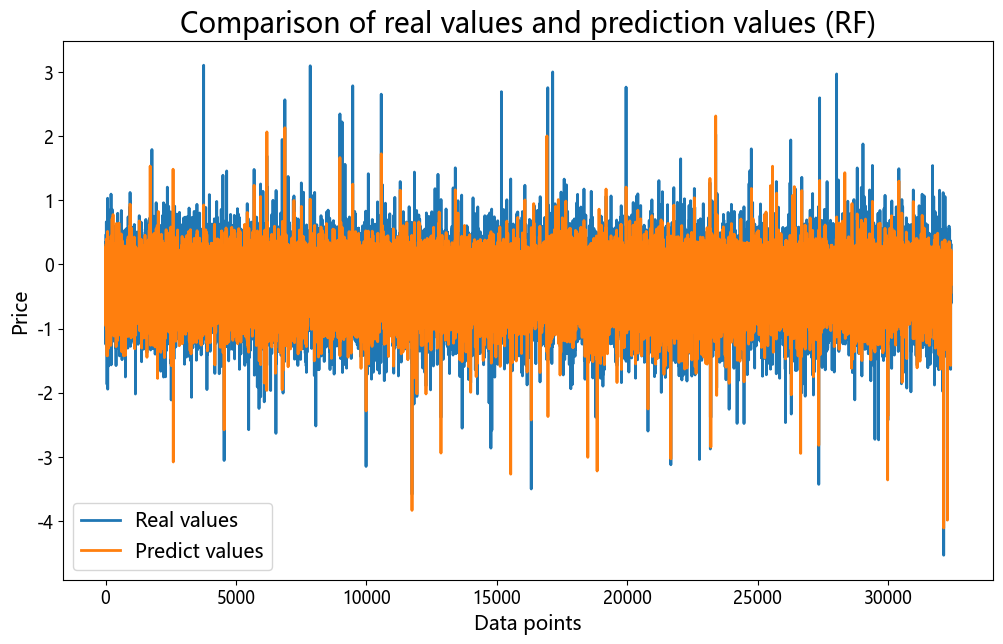

In [16]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(12, 7), dpi=100)  # 定义画布
ax.plot(y_test_of_rf, marker="", linestyle="-", linewidth=2, label="Real values")  # 画真实值
ax.plot(y_test_pred_of_rf, marker="", linestyle="-", linewidth=2, label="Predict values")  # 画预测值
ax.set_title("Comparison of real values and prediction values (RF)", fontsize=20)  # 标题
ax.set_xlabel("Data points", fontsize=14)  # x轴标签
ax.set_ylabel("Price", fontsize=14)  # y轴标签
ax.tick_params(labelsize=12)  # 设置坐标轴轴刻度大小
ax.legend(loc="best", prop={"size": 14})  # 图例
plt.show()  # 显示图像
plt.close()  # 关闭图像

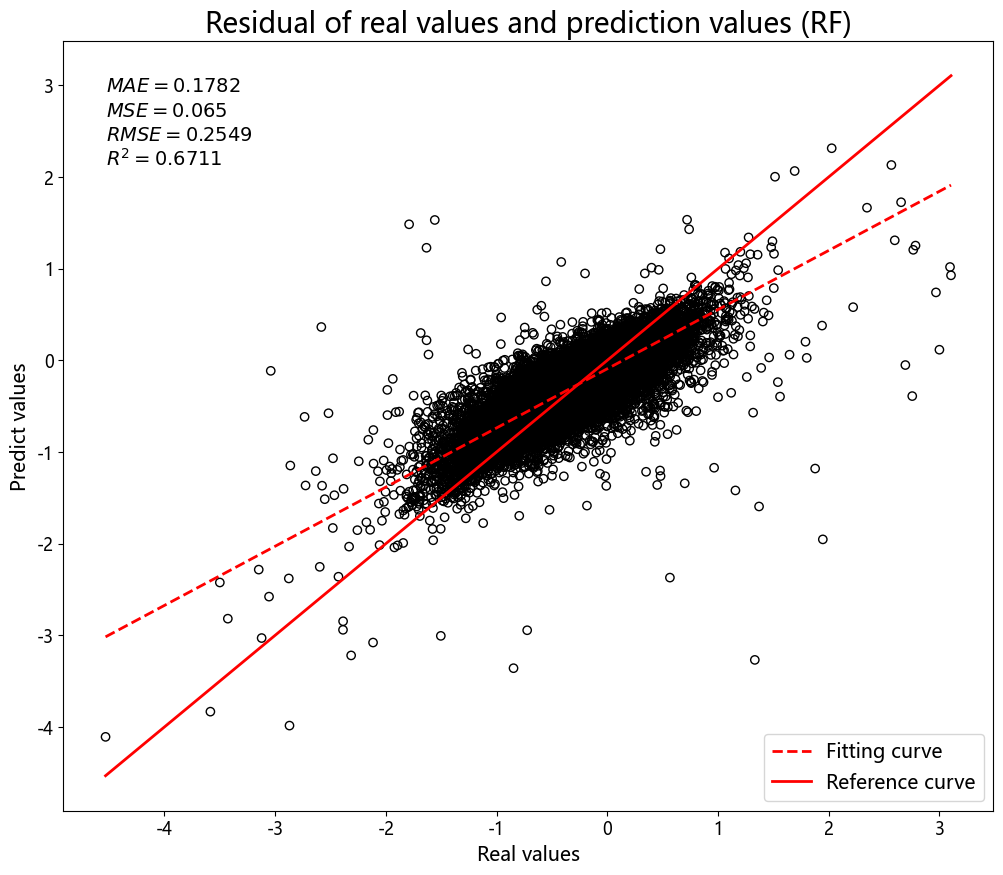

In [17]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(12, 10), dpi=100)  # 定义画布
ax.text(
    min(y_test_of_rf),
    max(y_test_of_rf),
    f"$MAE={round(mean_absolute_error(y_test_of_rf, y_test_pred_of_rf), 4)}$"
    f"\n$MSE={round(mean_squared_error(y_test_of_rf, y_test_pred_of_rf), 4)}$"
    f"\n$RMSE={round(pow(mean_squared_error(y_test_of_rf, y_test_pred_of_rf), 0.5), 4)}$"
    f"\n$R^2={round(r2_score(y_test_of_rf, y_test_pred_of_rf), 4)}$",
    verticalalignment="top",
    fontdict={"size": 14, "color": "k"},
)  # 左上角显示模型性能指标
ax.scatter(y_test_of_rf, y_test_pred_of_rf, c="none", marker="o", edgecolors="k")  # 散点图
if True:  # 是否画拟合曲线
    from sklearn.linear_model import LinearRegression
    fitting_model = LinearRegression()
    fitting_model.fit([[item] for item in y_test_of_rf], y_test_pred_of_rf)
    ax.plot(
        [min(y_test_of_rf), max(y_test_of_rf)],
        [
            fitting_model.predict([[min(y_test_of_rf)]]).item(),
            fitting_model.predict([[max(y_test_of_rf)]]).item(),
        ],
        linewidth=2,
        linestyle="--",
        color="r",
        label="Fitting curve",
    )  # 拟合曲线
ax.plot(
    [min(y_test_of_rf), max(y_test_of_rf)],
    [min(y_test_of_rf), max(y_test_of_rf)],
    linewidth=2,
    linestyle="-",
    color="r",
    label="Reference curve",
)  # 参考曲线
ax.set_title("Residual of real values and prediction values (RF)", fontsize=20)  # 标题
ax.set_xlabel("Real values", fontsize=14)  # x轴标签
ax.set_ylabel("Predict values", fontsize=14)  # y轴标签
ax.tick_params(labelsize=12)  # 设置坐标轴轴刻度大小
ax.legend(loc="lower right", prop={"size": 14})  # 图例
plt.show()  # 显示图像
plt.close()  # 关闭图像

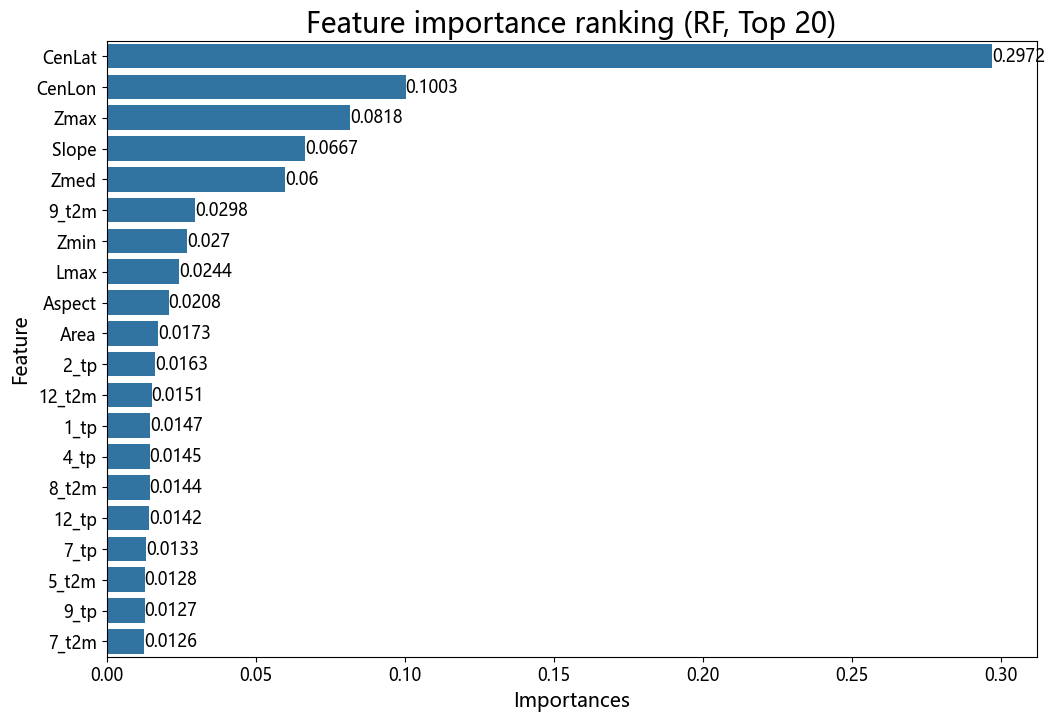

In [18]:
feature_columns_of_rf, feature_importances_of_rf = list(
    zip(
        *sorted(
            zip(feature_columns, rf_model.feature_importances_.tolist()),
            key=lambda x: x[1],
            reverse=True,
        ),
    )
)  # 特征重要度排序
feature_columns_of_rf = list(feature_columns_of_rf)[:20]  # 转换为列表
feature_importances_of_rf = list(feature_importances_of_rf)[:20]  # 转换为列表

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(12, 8), dpi=100)  # 定义画布
sns.barplot(x=feature_importances_of_rf, y=feature_columns_of_rf, ax=ax)  # 画条形图
for x, y in zip(range(len(feature_columns_of_rf)), [round(item, 4) for item in feature_importances_of_rf]):  # 遍历所有特征
    ax.text(x=y, y=x, s=round(y, 4), ha="left", va="center", fontdict={"size": 12})  # 在条形图上显示数字
ax.set_title("Feature importance ranking (RF, Top 20)", fontsize=20)  # 标题
ax.set_xlabel("Importances", fontsize=14)  # x轴标签
ax.set_ylabel("Feature", fontsize=14)  # y轴标签
ax.tick_params(labelsize=12)  # 设置坐标轴轴刻度大小
plt.show()  # 显示图像
plt.close()  # 关闭图像

feature_data = pd.DataFrame({
    'Feature': feature_columns_of_rf,
    'Importance': feature_importances_of_rf
})

# 保存为CSV文件
feature_data.to_csv('feature_importances_rf.csv', index=False)

### GBDT模型训练及评估

In [19]:
# 定义GBDT模型，并应用推荐的参数
gbdt_model = GradientBoostingRegressor(
    n_estimators=325,
    learning_rate= 0.026835560679333795,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=1,
    subsample=0.896900766485523,
    max_features=0.3797189038654494,
    random_state=42
)

gbdt_model.fit(X_train, y_train)  # 训练模型

save_pkl(os.path.join(outputs_dir, "gbdt_model.pkl"), gbdt_model)  # 保存模型

[outputs\gbdt_model.pkl] data saving...


In [20]:
# 预测训练集
y_train_pred_of_gbdt = gbdt_model.predict(X_train)

# 反标准化
y_train_of_gbdt = y_scaler.inverse_transform(y_train.reshape(-1, 1)).reshape(-1).tolist()
y_train_pred_of_gbdt = y_scaler.inverse_transform(y_train_pred_of_gbdt.reshape(-1, 1)).reshape(-1).tolist()

# 计算训练集指标
print("GBDT Model - Training Set:")
print(f"MAE: {mean_absolute_error(y_train_of_gbdt, y_train_pred_of_gbdt)}")  # 平均绝对误差
print(f"MSE: {mean_squared_error(y_train_of_gbdt, y_train_pred_of_gbdt)}")  # 均方误差
print(f"RMSE: {np.sqrt(mean_squared_error(y_train_of_gbdt, y_train_pred_of_gbdt))}")  # 均方根误差
print(f"R2: {r2_score(y_train_of_gbdt, y_train_pred_of_gbdt)}")  # R²

GBDT Model - Training Set:
MAE: 0.1498775600618998
MSE: 0.0393320365914168
RMSE: 0.19832306116893417
R2: 0.8004040836485269


In [21]:
y_test_pred_of_gbdt = gbdt_model.predict(X_test)  # 预测测试集数值

y_test_of_gbdt = y_scaler.inverse_transform(y_test.reshape(-1, 1)).reshape(-1).tolist()  # 反标准化
y_test_pred_of_gbdt = y_scaler.inverse_transform(y_test_pred_of_gbdt.reshape(-1, 1)).reshape(-1).tolist()  # 反标准化

print("GBDT Model:")
print(f"MAE: {mean_absolute_error(y_test_of_gbdt, y_test_pred_of_gbdt)}")  # 平均绝对误差
print(f"MSE: {mean_squared_error(y_test_of_gbdt, y_test_pred_of_gbdt)}")  # 均方误差
print(f"RMSE: {np.sqrt(mean_squared_error(y_test_of_gbdt, y_test_pred_of_gbdt))}")  # 均方根误差
print(f"R2: {r2_score(y_test_of_gbdt, y_test_pred_of_gbdt)}")  # R2

GBDT Model:
MAE: 0.1838132967435889
MSE: 0.06589079404640619
RMSE: 0.2566920217817573
R2: 0.6664253153551789


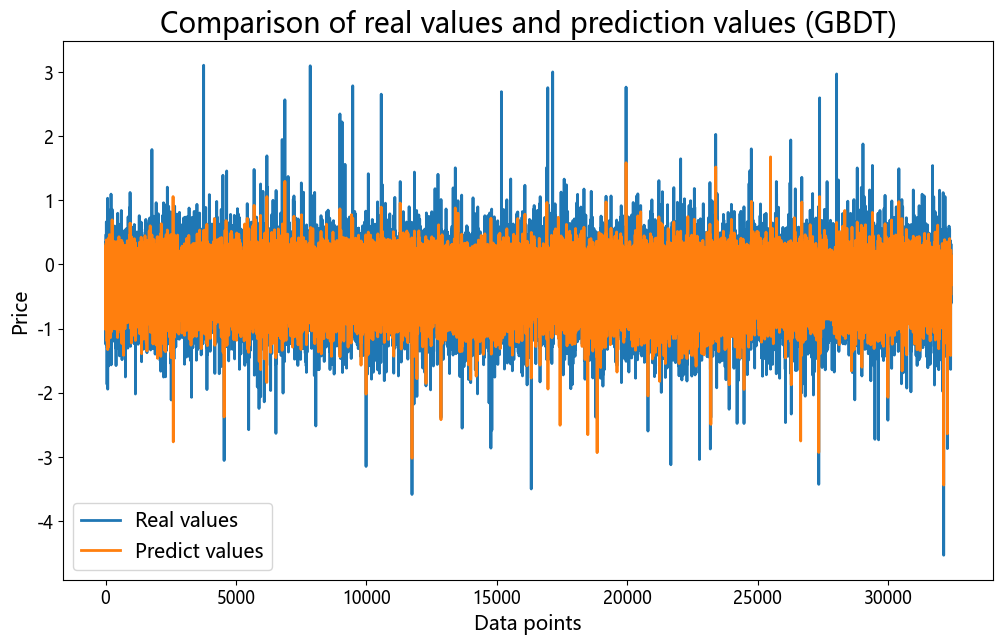

In [22]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(12, 7), dpi=100)  # 定义画布
ax.plot(y_test_of_gbdt, marker="", linestyle="-", linewidth=2, label="Real values")  # 画真实值
ax.plot(y_test_pred_of_gbdt, marker="", linestyle="-", linewidth=2, label="Predict values")  # 画预测值
ax.set_title("Comparison of real values and prediction values (GBDT)", fontsize=20)  # 标题
ax.set_xlabel("Data points", fontsize=14)  # x轴标签
ax.set_ylabel("Price", fontsize=14)  # y轴标签
ax.tick_params(labelsize=12)  # 设置坐标轴轴刻度大小
ax.legend(loc="best", prop={"size": 14})  # 图例
plt.show()  # 显示图像
plt.close()  # 关闭图像

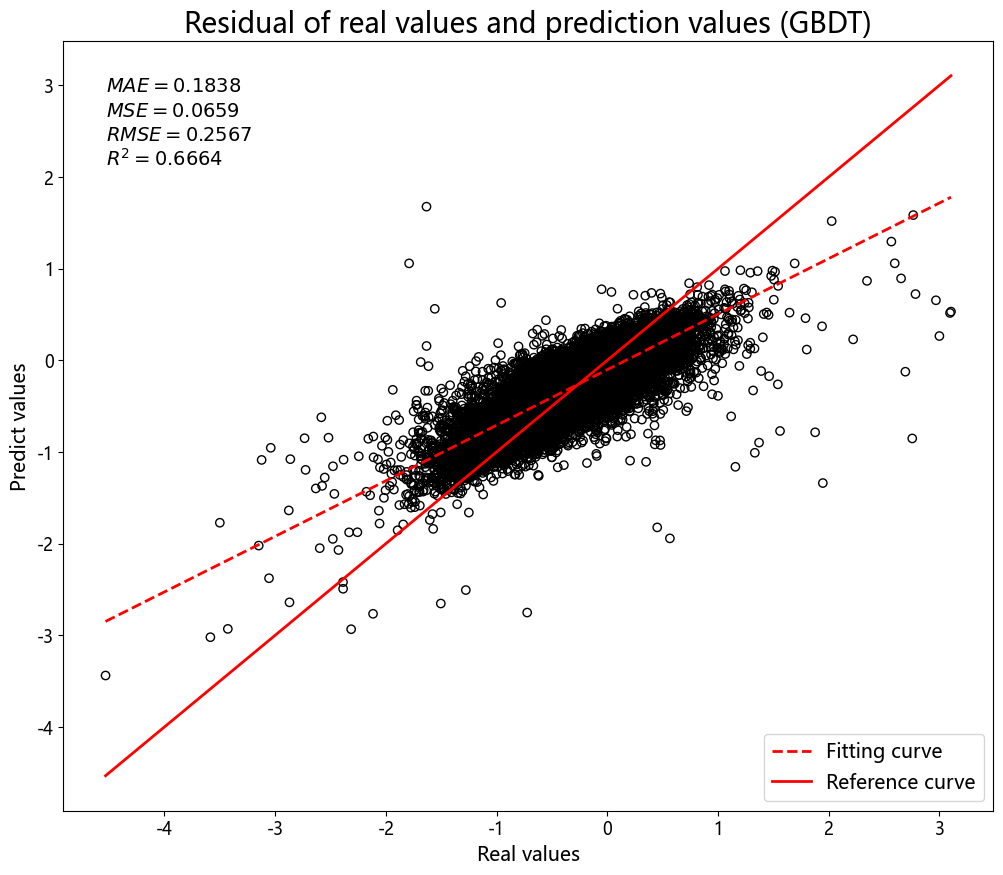

In [23]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(12, 10), dpi=100)  # 定义画布
ax.text(
    min(y_test_of_gbdt),
    max(y_test_of_gbdt),
    f"$MAE={round(mean_absolute_error(y_test_of_gbdt, y_test_pred_of_gbdt), 4)}$"
    f"\n$MSE={round(mean_squared_error(y_test_of_gbdt, y_test_pred_of_gbdt), 4)}$"
    f"\n$RMSE={round(pow(mean_squared_error(y_test_of_gbdt, y_test_pred_of_gbdt), 0.5), 4)}$"
    f"\n$R^2={round(r2_score(y_test_of_gbdt, y_test_pred_of_gbdt), 4)}$",
    verticalalignment="top",
    fontdict={"size": 14, "color": "k"},
)  # 左上角显示模型性能指标
ax.scatter(y_test_of_gbdt, y_test_pred_of_gbdt, c="none", marker="o", edgecolors="k")  # 散点图
if True:  # 是否画拟合曲线
    from sklearn.linear_model import LinearRegression
    fitting_model = LinearRegression()
    fitting_model.fit([[item] for item in y_test_of_gbdt], y_test_pred_of_gbdt)
    ax.plot(
        [min(y_test_of_gbdt), max(y_test_of_gbdt)],
        [
            fitting_model.predict([[min(y_test_of_gbdt)]]).item(),
            fitting_model.predict([[max(y_test_of_gbdt)]]).item(),
        ],
        linewidth=2,
        linestyle="--",
        color="r",
        label="Fitting curve",
    )  # 拟合曲线
ax.plot(
    [min(y_test_of_gbdt), max(y_test_of_gbdt)],
    [min(y_test_of_gbdt), max(y_test_of_gbdt)],
    linewidth=2,
    linestyle="-",
    color="r",
    label="Reference curve",
)  # 参考曲线
ax.set_title("Residual of real values and prediction values (GBDT)", fontsize=20)  # 标题
ax.set_xlabel("Real values", fontsize=14)  # x轴标签
ax.set_ylabel("Predict values", fontsize=14)  # y轴标签
ax.tick_params(labelsize=12)  # 设置坐标轴轴刻度大小
ax.legend(loc="lower right", prop={"size": 14})  # 图例
plt.show()  # 显示图像
plt.close()  # 关闭图像

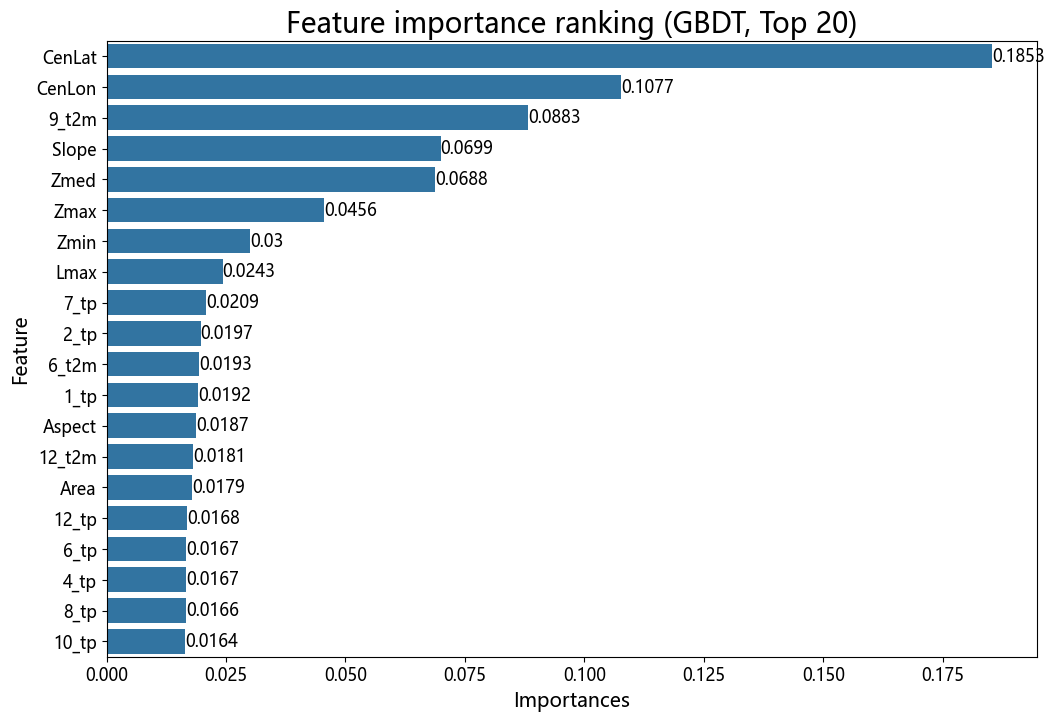

In [24]:
feature_columns_of_gbdt, feature_importances_of_gbdt = list(
    zip(
        *sorted(
            zip(feature_columns, gbdt_model.feature_importances_.tolist()),
            key=lambda x: x[1],
            reverse=True,
        ),
    )
)  # 特征重要度排序
feature_columns_of_gbdt = list(feature_columns_of_gbdt)[:20]  # 转换为列表
feature_importances_of_gbdt = list(feature_importances_of_gbdt)[:20]  # 转换为列表

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(12, 8), dpi=100)  # 定义画布
sns.barplot(x=feature_importances_of_gbdt, y=feature_columns_of_gbdt, ax=ax)  # 画条形图
for x, y in zip(range(len(feature_columns_of_gbdt)), [round(item, 4) for item in feature_importances_of_gbdt]):  # 遍历所有特征
    ax.text(x=y, y=x, s=round(y, 4), ha="left", va="center", fontdict={"size": 12})  # 在条形图上显示数字
ax.set_title("Feature importance ranking (GBDT, Top 20)", fontsize=20)  # 标题
ax.set_xlabel("Importances", fontsize=14)  # x轴标签
ax.set_ylabel("Feature", fontsize=14)  # y轴标签
ax.tick_params(labelsize=12)  # 设置坐标轴轴刻度大小
plt.show()  # 显示图像
plt.close()  # 关闭图像

# 创建一个DataFrame
feature_data = pd.DataFrame({
    'Feature': feature_columns_of_gbdt,
    'Importance': feature_importances_of_gbdt
})

# 保存为CSV文件
feature_data.to_csv('feature_importances_gbdt.csv', index=False)

### ANN模型训练及评估

In [25]:
ann_model = MLPRegressor(hidden_layer_sizes=(83, 100, 14), 
    alpha= 0.002307946838380127,
    learning_rate_init= 0.007066923434750849,
    batch_size=32, 
    max_iter=500, 
    random_state=42)  # 定义ANN模型
ann_model.fit(X_train, y_train)  # 训练模型

save_pkl(os.path.join(outputs_dir, "ann_model.pkl"), ann_model)  # 保存模型

[outputs\ann_model.pkl] data saving...


In [26]:
# 预测训练集
y_train_pred_of_ann = ann_model.predict(X_train)

# 反标准化
y_train_of_ann = y_scaler.inverse_transform(y_train.reshape(-1, 1)).reshape(-1).tolist()
y_train_pred_of_ann = y_scaler.inverse_transform(y_train_pred_of_ann.reshape(-1, 1)).reshape(-1).tolist()

# 计算训练集指标
print("ANN Model - Training Set:")
print(f"MAE: {mean_absolute_error(y_train_of_ann, y_train_pred_of_ann)}")  # 平均绝对误差
print(f"MSE: {mean_squared_error(y_train_of_ann, y_train_pred_of_ann)}")  # 均方误差
print(f"RMSE: {np.sqrt(mean_squared_error(y_train_of_ann, y_train_pred_of_ann))}")  # 均方根误差
print(f"R2: {r2_score(y_train_of_ann, y_train_pred_of_ann)}")  # R²

ANN Model - Training Set:
MAE: 0.23377515347184288
MSE: 0.1050730584043907
RMSE: 0.32414974688311987
R2: 0.4667920811236902


In [27]:
y_test_pred_of_ann = ann_model.predict(X_test)  # 预测测试集数值

y_test_of_ann = y_scaler.inverse_transform(y_test.reshape(-1, 1)).reshape(-1).tolist()  # 反标准化
y_test_pred_of_ann = y_scaler.inverse_transform(y_test_pred_of_ann.reshape(-1, 1)).reshape(-1).tolist()  # 反标准化

print("ANN Model:")
print(f"MAE: {mean_absolute_error(y_test_of_ann, y_test_pred_of_ann)}")  # 平均绝对误差
print(f"MSE: {mean_squared_error(y_test_of_ann, y_test_pred_of_ann)}")  # 均方误差
print(f"RMSE: {np.sqrt(mean_squared_error(y_test_of_ann, y_test_pred_of_ann))}")  # 均方根误差
print(f"R2: {r2_score(y_test_of_ann, y_test_pred_of_ann)}")  # R2

ANN Model:
MAE: 0.23514734966288364
MSE: 0.10525359938361546
RMSE: 0.32442811127215143
R2: 0.4671495960817482


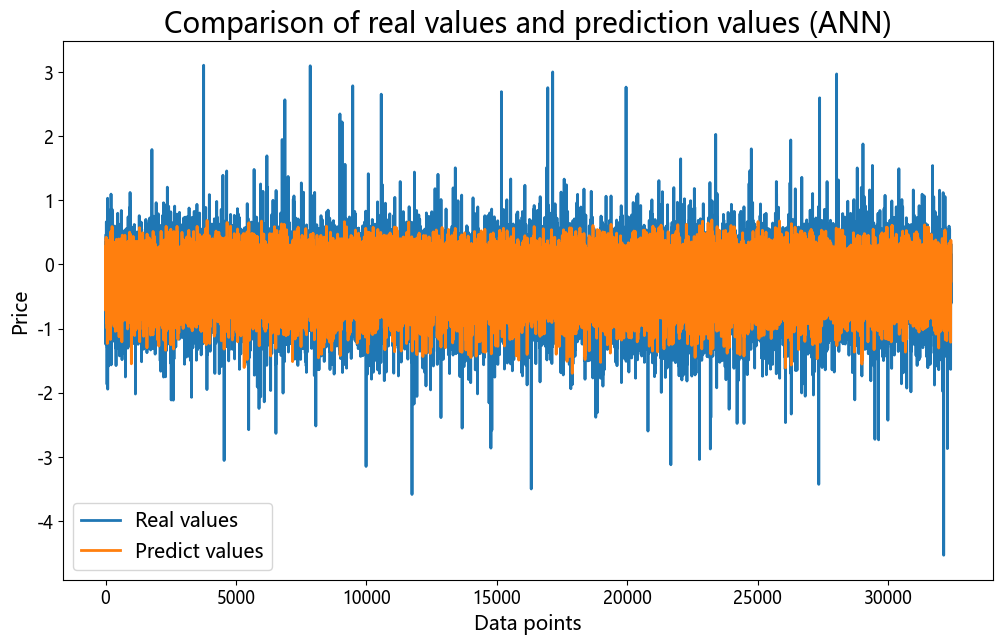

In [28]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(12, 7), dpi=100)  # 定义画布
ax.plot(y_test_of_ann, marker="", linestyle="-", linewidth=2, label="Real values")  # 画真实值
ax.plot(y_test_pred_of_ann, marker="", linestyle="-", linewidth=2, label="Predict values")  # 画预测值
ax.set_title("Comparison of real values and prediction values (ANN)", fontsize=20)  # 标题
ax.set_xlabel("Data points", fontsize=14)  # x轴标签
ax.set_ylabel("Price", fontsize=14)  # y轴标签
ax.tick_params(labelsize=12)  # 设置坐标轴轴刻度大小
ax.legend(loc="best", prop={"size": 14})  # 图例
plt.show()  # 显示图像
plt.close()  # 关闭图像

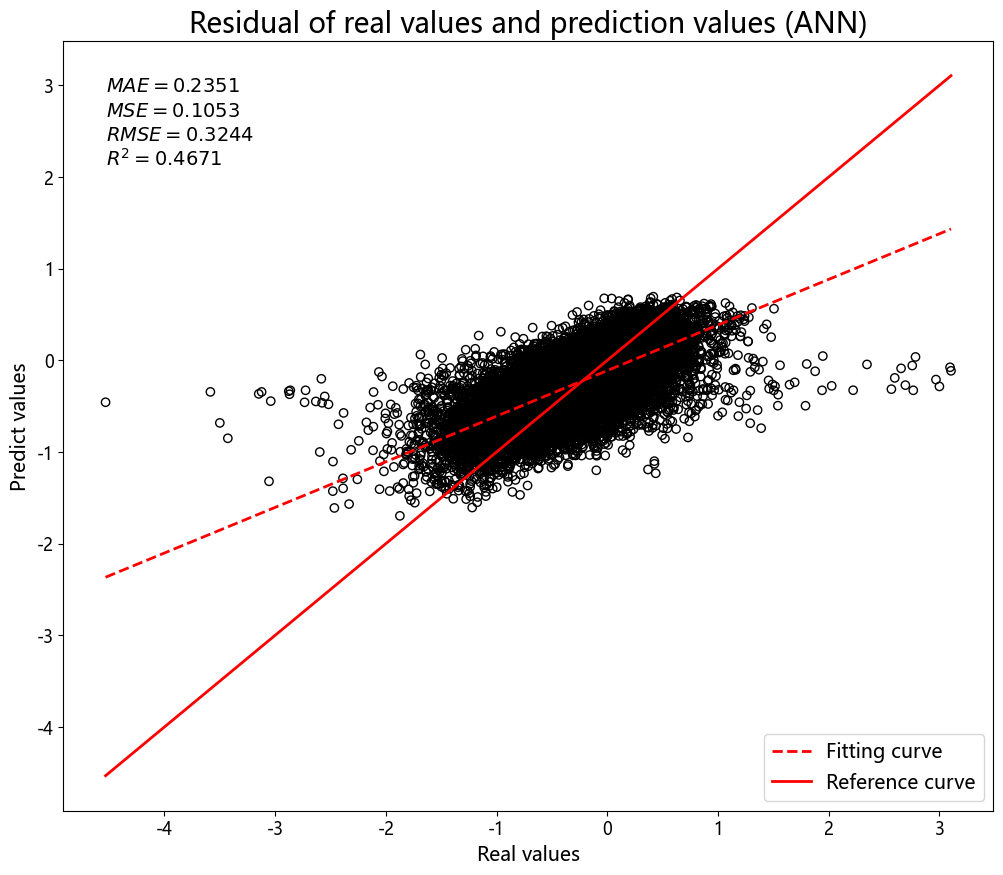

In [29]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(12, 10), dpi=100)  # 定义画布
ax.text(
    min(y_test_of_ann),
    max(y_test_of_ann),
    f"$MAE={round(mean_absolute_error(y_test_of_ann, y_test_pred_of_ann), 4)}$"
    f"\n$MSE={round(mean_squared_error(y_test_of_ann, y_test_pred_of_ann), 4)}$"
    f"\n$RMSE={round(pow(mean_squared_error(y_test_of_ann, y_test_pred_of_ann), 0.5), 4)}$"
    f"\n$R^2={round(r2_score(y_test_of_ann, y_test_pred_of_ann), 4)}$",
    verticalalignment="top",
    fontdict={"size": 14, "color": "k"},
)  # 左上角显示模型性能指标
ax.scatter(y_test_of_ann, y_test_pred_of_ann, c="none", marker="o", edgecolors="k")  # 散点图
if True:  # 是否画拟合曲线
    from sklearn.linear_model import LinearRegression
    fitting_model = LinearRegression()
    fitting_model.fit([[item] for item in y_test_of_ann], y_test_pred_of_ann)
    ax.plot(
        [min(y_test_of_ann), max(y_test_of_ann)],
        [
            fitting_model.predict([[min(y_test_of_ann)]]).item(),
            fitting_model.predict([[max(y_test_of_ann)]]).item(),
        ],
        linewidth=2,
        linestyle="--",
        color="r",
        label="Fitting curve",
    )  # 拟合曲线
ax.plot(
    [min(y_test_of_ann), max(y_test_of_ann)],
    [min(y_test_of_ann), max(y_test_of_ann)],
    linewidth=2,
    linestyle="-",
    color="r",
    label="Reference curve",
)  # 参考曲线
ax.set_title("Residual of real values and prediction values (ANN)", fontsize=20)  # 标题
ax.set_xlabel("Real values", fontsize=14)  # x轴标签
ax.set_ylabel("Predict values", fontsize=14)  # y轴标签
ax.tick_params(labelsize=12)  # 设置坐标轴轴刻度大小
ax.legend(loc="lower right", prop={"size": 14})  # 图例
plt.show()  # 显示图像
plt.close()  # 关闭图像

### BP模型训练及评估

In [30]:
def setup_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.enabled = False

    os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":16:8"

    torch.use_deterministic_algorithms(True)

setup_seed(seed=42)  # 设置随机种子

In [31]:
class Datasets(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        assert len(self.X) == len(self.y)
        return len(self.y)

    def __getitem__(self, index):
        return torch.FloatTensor(self.X[index]), torch.FloatTensor(self.y[index])

In [32]:
class BPModel(nn.Module):
    def __init__(self, inputs_size, outputs_size):
        super(BPModel, self).__init__()
        self.linear1 = nn.Linear(inputs_size, 229)  # hidden_size1
        self.linear2 = nn.Linear(229, 207)  # hidden_size2
        self.predict = nn.Linear(207, outputs_size)  # 输出层
        self.activation = nn.PReLU()  # 激活层
        self.dropout = nn.Dropout(0.10290269337601031)  # dropout_rate

    def forward(self, inputs):
        outputs = self.linear1(inputs)
        outputs = self.activation(outputs)
        outputs = self.dropout(outputs)
        outputs = self.linear2(outputs)
        outputs = self.activation(outputs)
        outputs = self.dropout(outputs)
        outputs = self.predict(outputs)
        return outputs

In [33]:
batch_size = 128  # 最佳 batch_size
epochs = 1000  # 训练轮数保持不变
learning_rate = 0.0022005828785027445  # 最佳 learning_rate
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")  # 设备

print("Device:", device)  # 打印设备

Device: cpu


In [34]:
train_datasets = Datasets(X_train, [[item] for item in y_train])  # 训练集
test_datasets = Datasets(X_test, [[item] for item in y_test])  # 测试集

train_loader = DataLoader(train_datasets, batch_size=batch_size, shuffle=True, num_workers=0, drop_last=False)  # 训练集加载器
test_loader = DataLoader(test_datasets, batch_size=batch_size, shuffle=False, num_workers=0, drop_last=False)  # 测试集加载器

In [35]:
bp_model = BPModel(inputs_size=X_train.shape[-1], outputs_size=1).to(device)  # 定义模型
optimizer = torch.optim.Adam(bp_model.parameters(), lr=learning_rate)  # 优化器
criterion = torch.nn.MSELoss()  # 损失函数

In [36]:
best_test_r2 = 0  # 最好的测试集R2
train_r2_records = []  # 训练集R2记录
train_loss_records = []  # 训练集Loss记录
test_r2_records = []  # 测试集R2记录
test_loss_records = []  # 测试集Loss记录
for epoch in range(1, epochs + 1):  # 循环每一个epoch
    bp_model.train()  # 训练模式
    train_real_targets = []  # 训练集真实值
    train_pred_targets = []  # 训练集预测值
    train_loss_logs = []  # 训练集Loss记录
    for inputs, targets in tqdm(train_loader, file=sys.stdout):  # 循环每一个batch
        outputs = bp_model(inputs.to(device))  # 前向传播
        loss = criterion(outputs, targets.to(device))  # 计算Loss
        optimizer.zero_grad()  # 梯度清零
        loss.backward()  # 反向传播
        optimizer.step()  # 更新参数
        train_real_targets.extend(targets.numpy().tolist())  # 记录真实值
        train_pred_targets.extend(outputs.detach().cpu().numpy().tolist())  # 记录预测值
        train_loss_logs.append(loss.item())  # 记录Loss
    train_r2 = round(r2_score(train_real_targets, train_pred_targets), 4)  # 计算R2
    train_loss = round(sum(train_loss_logs) / len(train_loss_logs), 4)  # 求loss均值
    print(f"Epoch: {epoch} / {epochs}, Train R2: {train_r2:.4f}, Train Loss: {train_loss:4f}")

    bp_model.eval()  # 测试模式
    test_real_targets = []  # 测试集真实值
    test_pred_targets = []  # 测试集预测值
    test_loss_logs = []  # 测试集Loss记录
    for inputs, targets in tqdm(test_loader, file=sys.stdout):  # 循环每一个batch
        outputs = bp_model(inputs.to(device))  # 前向传播
        loss = criterion(outputs, targets.to(device))  # 计算Loss
        test_real_targets.extend(targets.numpy().tolist())  # 记录真实值
        test_pred_targets.extend(outputs.detach().cpu().numpy().tolist())  # 记录预测值
        test_loss_logs.append(loss.item())  # 记录Loss
    test_r2 = round(r2_score(test_real_targets, test_pred_targets), 4)  # 计算R2
    test_loss = round(sum(test_loss_logs) / len(test_loss_logs), 4)  # 求loss均值
    print(f"Epoch: {epoch} / {epochs}, Test R2: {test_r2}, Test Loss: {test_loss}")

    if test_r2 > best_test_r2:  # 保存最好的模型
        best_test_r2 = test_r2  # 更新最好的测试集R2
        torch.save(bp_model.state_dict(), os.path.join(outputs_dir, "bp_model.pt"))  # 保存模型
    print(f"Best test r2: {best_test_r2:.4f}")

    train_r2_records.append(train_r2)  # 记录训练集R2
    train_loss_records.append(train_loss)  # 记录训练集Loss
    test_r2_records.append(test_r2)  # 记录测试集R2
    test_loss_records.append(test_loss)  # 记录测试集Loss

print("Done! Best test r2:", best_test_r2)

100%|██████████| 1013/1013 [00:06<00:00, 150.21it/s]
Epoch: 1 / 1000, Train R2: 0.4015, Train Loss: 0.598400
100%|██████████| 254/254 [00:01<00:00, 246.33it/s]
Epoch: 1 / 1000, Test R2: 0.4472, Test Loss: 0.5535
Best test r2: 0.4472
100%|██████████| 1013/1013 [00:06<00:00, 148.72it/s]
Epoch: 2 / 1000, Train R2: 0.4497, Train Loss: 0.550400
100%|██████████| 254/254 [00:00<00:00, 260.88it/s]
Epoch: 2 / 1000, Test R2: 0.458, Test Loss: 0.5428
Best test r2: 0.4580
100%|██████████| 1013/1013 [00:06<00:00, 153.12it/s]
Epoch: 3 / 1000, Train R2: 0.4689, Train Loss: 0.531100
100%|██████████| 254/254 [00:00<00:00, 268.46it/s]
Epoch: 3 / 1000, Test R2: 0.4925, Test Loss: 0.5082
Best test r2: 0.4925
100%|██████████| 1013/1013 [00:06<00:00, 150.39it/s]
Epoch: 4 / 1000, Train R2: 0.4841, Train Loss: 0.515900
100%|██████████| 254/254 [00:00<00:00, 256.85it/s]
Epoch: 4 / 1000, Test R2: 0.4962, Test Loss: 0.5044
Best test r2: 0.4962
100%|██████████| 1013/1013 [00:06<00:00, 153.94it/s]
Epoch: 5 / 1000,

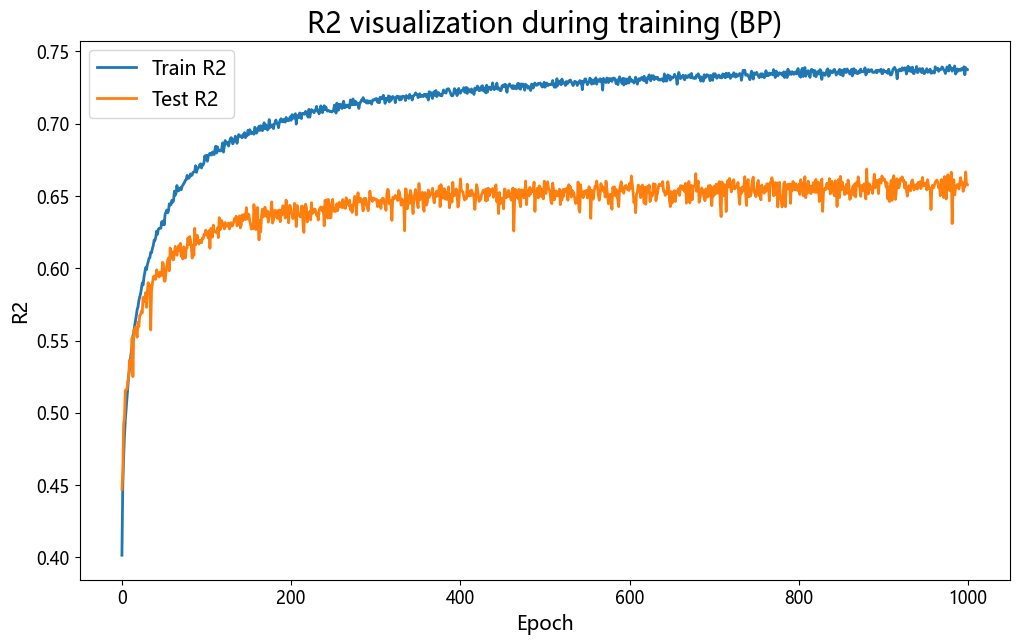

In [37]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(12, 7), dpi=100)  # 定义画布
ax.plot(train_r2_records, marker="", linestyle="-", linewidth=2, label="Train R2")  # 画训练集R2曲线
ax.plot(test_r2_records, marker="", linestyle="-", linewidth=2, label="Test R2")  # 画测试集R2曲线
ax.set_title("R2 visualization during training (BP)", fontsize=20)  # 标题
ax.set_xlabel("Epoch", fontsize=14)  # x轴标签
ax.set_ylabel("R2", fontsize=14)  # y轴标签
ax.tick_params(labelsize=12)  # 设置坐标轴轴刻度大小
ax.legend(loc="best", prop={"size": 14})  # 图例
plt.show()  # 显示图像
plt.close()  # 关闭图像

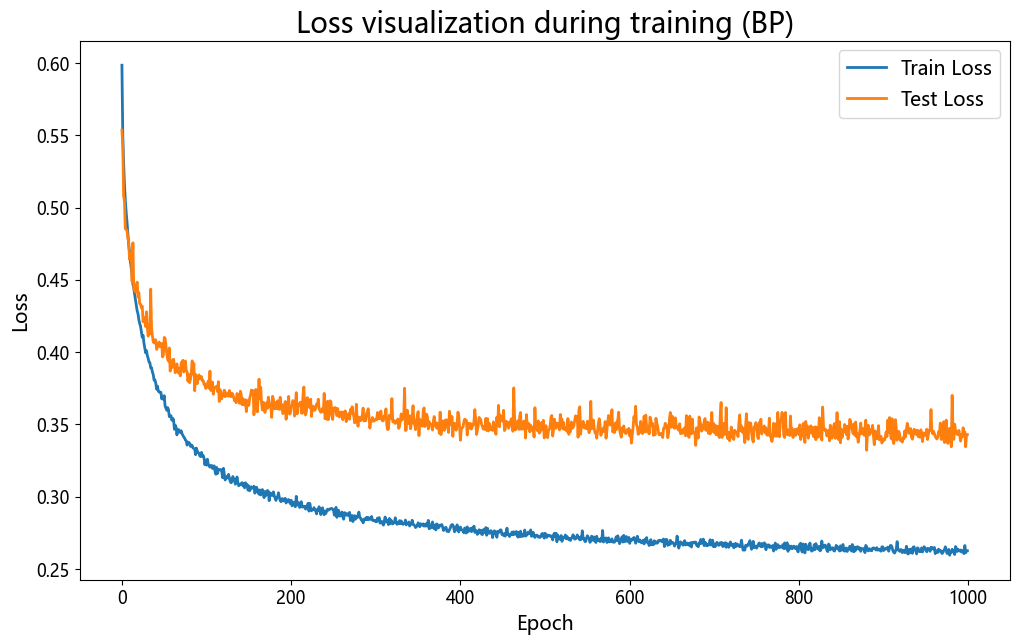

In [38]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(12, 7), dpi=100)  # 定义画布
ax.plot(train_loss_records, marker="", linestyle="-", linewidth=2, label="Train Loss")  # 画训练集Loss曲线
ax.plot(test_loss_records, marker="", linestyle="-", linewidth=2, label="Test Loss")  # 画测试集Loss曲线
ax.set_title("Loss visualization during training (BP)", fontsize=20)  # 标题
ax.set_xlabel("Epoch", fontsize=14)  # x轴标签
ax.set_ylabel("Loss", fontsize=14)  # y轴标签
ax.tick_params(labelsize=12)  # 设置坐标轴轴刻度大小
ax.legend(loc="best", prop={"size": 14})  # 图例
plt.show()  # 显示图像
plt.close()  # 关闭图像

In [39]:
bp_model = BPModel(inputs_size=X_train.shape[-1], outputs_size=1).to(device)  # 定义模型
bp_model.load_state_dict(torch.load(os.path.join(outputs_dir, "bp_model.pt")))  # 加载模型
bp_model.eval()  # 测试模式

# 预测训练集
y_train_pred_of_bp = []  # 存储训练集预测值
for inputs, targets in tqdm(train_loader, file=sys.stdout):  # 训练集批量预测
    outputs = bp_model(inputs.to(device))  # 前向传播
    y_train_pred_of_bp.extend(outputs.detach().cpu().numpy().tolist())  # 记录预测值

# 反标准化
y_train_of_bp = y_scaler.inverse_transform(y_train.reshape(-1, 1)).reshape(-1).tolist()
y_train_pred_of_bp = y_scaler.inverse_transform(y_train_pred_of_bp).reshape(-1).tolist()

# 计算训练集指标
print("BP Model - Training Set:")
print(f"MAE: {mean_absolute_error(y_train_of_bp, y_train_pred_of_bp)}")  # 平均绝对误差
print(f"MSE: {mean_squared_error(y_train_of_bp, y_train_pred_of_bp)}")  # 均方误差
print(f"RMSE: {np.sqrt(mean_squared_error(y_train_of_bp, y_train_pred_of_bp))}")  # 均方根误差
print(f"R2: {r2_score(y_train_of_bp, y_train_pred_of_bp)}")  # R²

y_test_pred_of_bp = []  # 测试集预测值
for inputs, targets in tqdm(test_loader, file=sys.stdout):  # 循环每一个batch
    outputs = bp_model(inputs.to(device))  # 前向传播
    y_test_pred_of_bp.extend(outputs.detach().cpu().numpy().tolist())  # 记录预测值

y_test_of_bp = y_scaler.inverse_transform(y_test.reshape(-1, 1)).reshape(-1).tolist()  # 反标准化
y_test_pred_of_bp = y_scaler.inverse_transform(y_test_pred_of_bp).reshape(-1).tolist()  # 反标准化

print("BP Model:")
print(f"MAE: {mean_absolute_error(y_test_of_bp, y_test_pred_of_bp)}")  # 平均绝对误差
print(f"MSE: {mean_squared_error(y_test_of_bp, y_test_pred_of_bp)}")  # 均方误差
print(f"RMSE: {np.sqrt(mean_squared_error(y_test_of_bp, y_test_pred_of_bp))}")  # 均方根误差
print(f"R2: {r2_score(y_test_of_bp, y_test_pred_of_bp)}")  # R2

  0%|          | 0/1013 [00:00<?, ?it/s]

100%|██████████| 1013/1013 [00:04<00:00, 244.01it/s]
BP Model - Training Set:
MAE: 0.4430371463216396
MSE: 0.3339751591907721
RMSE: 0.5779058393810985
R2: -0.6948036184797539
100%|██████████| 254/254 [00:00<00:00, 266.15it/s]
BP Model:
MAE: 0.18890401140777013
MSE: 0.06546397944050189
RMSE: 0.2558592961776099
R2: 0.6685860807492954


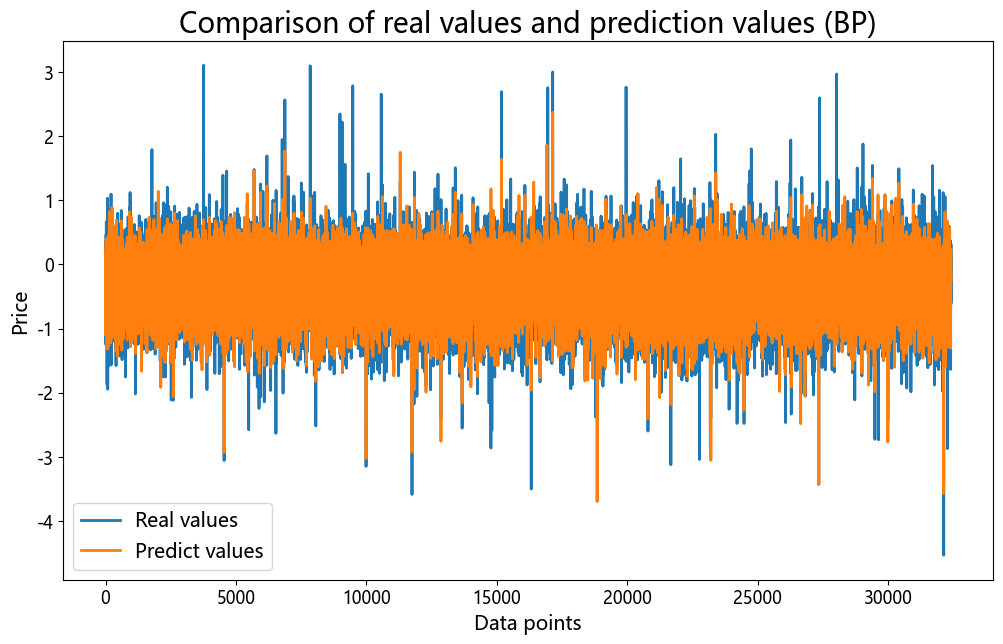

In [40]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(12, 7), dpi=100)  # 定义画布
ax.plot(y_test_of_bp, marker="", linestyle="-", linewidth=2, label="Real values")  # 画真实值
ax.plot(y_test_pred_of_bp, marker="", linestyle="-", linewidth=2, label="Predict values")  # 画预测值
ax.set_title("Comparison of real values and prediction values (BP)", fontsize=20)  # 标题
ax.set_xlabel("Data points", fontsize=14)  # x轴标签
ax.set_ylabel("Price", fontsize=14)  # y轴标签
ax.tick_params(labelsize=12)  # 设置坐标轴轴刻度大小
ax.legend(loc="best", prop={"size": 14})  # 图例
plt.show()  # 显示图像
plt.close()  # 关闭图像

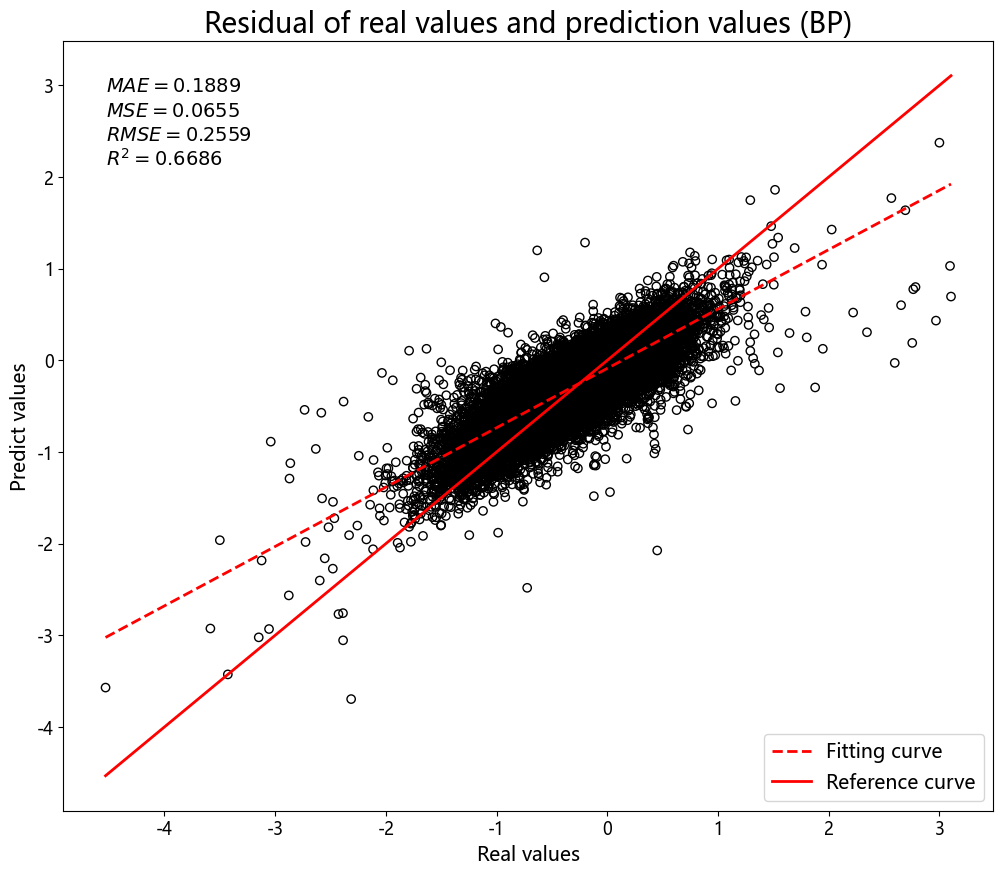

In [41]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(12, 10), dpi=100)  # 定义画布
ax.text(
    min(y_test_of_bp),
    max(y_test_of_bp),
    f"$MAE={round(mean_absolute_error(y_test_of_bp, y_test_pred_of_bp), 4)}$"
    f"\n$MSE={round(mean_squared_error(y_test_of_bp, y_test_pred_of_bp), 4)}$"
    f"\n$RMSE={round(pow(mean_squared_error(y_test_of_bp, y_test_pred_of_bp), 0.5), 4)}$"
    f"\n$R^2={round(r2_score(y_test_of_bp, y_test_pred_of_bp), 4)}$",
    verticalalignment="top",
    fontdict={"size": 14, "color": "k"},
)  # 左上角显示模型性能指标
ax.scatter(y_test_of_bp, y_test_pred_of_bp, c="none", marker="o", edgecolors="k")  # 散点图
if True:  # 是否画拟合曲线
    from sklearn.linear_model import LinearRegression
    fitting_model = LinearRegression()
    fitting_model.fit([[item] for item in y_test_of_bp], y_test_pred_of_bp)
    ax.plot(
        [min(y_test_of_bp), max(y_test_of_bp)],
        [
            fitting_model.predict([[min(y_test_of_bp)]]).item(),
            fitting_model.predict([[max(y_test_of_bp)]]).item(),
        ],
        linewidth=2,
        linestyle="--",
        color="r",
        label="Fitting curve",
    )  # 拟合曲线
ax.plot(
    [min(y_test_of_bp), max(y_test_of_bp)],
    [min(y_test_of_bp), max(y_test_of_bp)],
    linewidth=2,
    linestyle="-",
    color="r",
    label="Reference curve",
)  # 参考曲线
ax.set_title("Residual of real values and prediction values (BP)", fontsize=20)  # 标题
ax.set_xlabel("Real values", fontsize=14)  # x轴标签
ax.set_ylabel("Predict values", fontsize=14)  # y轴标签
ax.tick_params(labelsize=12)  # 设置坐标轴轴刻度大小
ax.legend(loc="lower right", prop={"size": 14})  # 图例
plt.show()  # 显示图像
plt.close()  # 关闭图像

### LSTM模型训练及评估

In [42]:
def setup_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.enabled = False

    os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":16:8"

    torch.use_deterministic_algorithms(True)

setup_seed(seed=42)  # 设置随机种子

In [43]:
class Datasets(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        assert len(self.X) == len(self.y)
        return len(self.y)

    def __getitem__(self, index):
        return torch.FloatTensor(self.X[index]), torch.FloatTensor(self.y[index])

In [44]:
class LSTMModel(nn.Module):
    def __init__(self, inputs_size, outputs_size, hidden_size=226, num_layers=3, dropout_rate=0.2586884835506128, bidirectional=True):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(
            input_size=inputs_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout_rate,
            bidirectional=bidirectional
        )  # LSTM层
        self.predict = nn.Linear(hidden_size * 2 if bidirectional else hidden_size, outputs_size)  # 预测层，考虑双向时隐藏层大小会变为2倍
        self.activation = nn.PReLU()  # 激活层
        self.dropout = nn.Dropout(dropout_rate)  # dropout层

    def lstm_forward(self, inputs):  # torch.Size([B, 1, F])
        outputs, (h_n, c_n) = self.lstm(inputs)  # torch.Size([B, 1, 128])，如果是双向的话，输出大小会是[2*hidden_size]
        outputs = self.activation(outputs)  # torch.Size([B, 1, 128])
        outputs = outputs[:, -1, :]  # 取LSTM输出的最后一个时间步的输出
        return outputs

    def forward(self, inputs):  # torch.Size([B, F])
        outputs = self.lstm_forward(inputs.unsqueeze(dim=1))  # torch.Size([B, 1, F])

        outputs = self.dropout(outputs)  # torch.Size([B, 128])
        outputs = self.predict(outputs)  # torch.Size([B, 1])
        return outputs
        return outputs

In [45]:
batch_size = 128  # 批次大小
epochs = 1000  # 训练轮数
learning_rate = 0.0009199904113154418
hidden_size = 218  # 隐藏层大小
num_layers = 3  # LSTM层数
dropout_rate = 0.2851846414906849
bidirectional = True  # 是否双向
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")  # 设备

print("Device:", device)  # 打印设备

Device: cpu


In [46]:
train_datasets = Datasets(X_train, [[item] for item in y_train])  # 训练集
test_datasets = Datasets(X_test, [[item] for item in y_test])  # 测试集

train_loader = DataLoader(train_datasets, batch_size=batch_size, shuffle=True, num_workers=0, drop_last=False)  # 训练集加载器
test_loader = DataLoader(test_datasets, batch_size=batch_size, shuffle=False, num_workers=0, drop_last=False)  # 测试集加载器

In [47]:
lstm_model = LSTMModel(inputs_size=X_train.shape[-1], outputs_size=1).to(device)  # 定义模型
optimizer = torch.optim.Adam(lstm_model.parameters(), lr=learning_rate)  # 优化器
criterion = torch.nn.MSELoss()  # 损失函数

In [48]:
best_test_r2 = 0  # 最好的测试集R2
train_r2_records = []  # 训练集R2记录
train_loss_records = []  # 训练集Loss记录
test_r2_records = []  # 测试集R2记录
test_loss_records = []  # 测试集Loss记录
for epoch in range(1, epochs + 1):  # 循环每一个epoch
    lstm_model.train()  # 训练模式
    train_real_targets = []  # 训练集真实值
    train_pred_targets = []  # 训练集预测值
    train_loss_logs = []  # 训练集Loss记录
    for inputs, targets in tqdm(train_loader, file=sys.stdout):  # 循环每一个batch
        outputs = lstm_model(inputs.to(device))  # 前向传播
        loss = criterion(outputs, targets.to(device))  # 计算Loss
        optimizer.zero_grad()  # 梯度清零
        loss.backward()  # 反向传播
        optimizer.step()  # 更新参数
        train_real_targets.extend(targets.numpy().tolist())  # 记录真实值
        train_pred_targets.extend(outputs.detach().cpu().numpy().tolist())  # 记录预测值
        train_loss_logs.append(loss.item())  # 记录Loss
    train_r2 = round(r2_score(train_real_targets, train_pred_targets), 4)  # 计算R2
    train_loss = round(sum(train_loss_logs) / len(train_loss_logs), 4)  # 求loss均值
    print(f"Epoch: {epoch} / {epochs}, Train R2: {train_r2:.4f}, Train Loss: {train_loss:4f}")

    lstm_model.eval()  # 测试模式
    test_real_targets = []  # 测试集真实值
    test_pred_targets = []  # 测试集预测值
    test_loss_logs = []  # 测试集Loss记录
    for inputs, targets in tqdm(test_loader, file=sys.stdout):  # 循环每一个batch
        outputs = lstm_model(inputs.to(device))  # 前向传播
        loss = criterion(outputs, targets.to(device))  # 计算Loss
        test_real_targets.extend(targets.numpy().tolist())  # 记录真实值
        test_pred_targets.extend(outputs.detach().cpu().numpy().tolist())  # 记录预测值
        test_loss_logs.append(loss.item())  # 记录Loss
    test_r2 = round(r2_score(test_real_targets, test_pred_targets), 4)  # 计算R2
    test_loss = round(sum(test_loss_logs) / len(test_loss_logs), 4)  # 求loss均值
    print(f"Epoch: {epoch} / {epochs}, Test R2: {test_r2}, Test Loss: {test_loss}")

    if test_r2 > best_test_r2:  # 保存最好的模型
        best_test_r2 = test_r2  # 更新最好的测试集R2
        torch.save(lstm_model.state_dict(), os.path.join(outputs_dir, "lstm_model.pt"))  # 保存模型
    print(f"Best test r2: {best_test_r2:.4f}")

    train_r2_records.append(train_r2)  # 记录训练集R2
    train_loss_records.append(train_loss)  # 记录训练集Loss
    test_r2_records.append(test_r2)  # 记录测试集R2
    test_loss_records.append(test_loss)  # 记录测试集Loss

print("Done! Best test r2:", best_test_r2)

100%|██████████| 1013/1013 [00:36<00:00, 27.59it/s]
Epoch: 1 / 1000, Train R2: 0.3900, Train Loss: 0.610000
100%|██████████| 254/254 [00:03<00:00, 84.07it/s]
Epoch: 1 / 1000, Test R2: 0.4355, Test Loss: 0.5655
Best test r2: 0.4355
100%|██████████| 1013/1013 [00:36<00:00, 27.55it/s]
Epoch: 2 / 1000, Train R2: 0.4325, Train Loss: 0.567400
100%|██████████| 254/254 [00:02<00:00, 85.39it/s]
Epoch: 2 / 1000, Test R2: 0.4471, Test Loss: 0.5539
Best test r2: 0.4471
100%|██████████| 1013/1013 [00:36<00:00, 27.45it/s]
Epoch: 3 / 1000, Train R2: 0.4499, Train Loss: 0.550100
100%|██████████| 254/254 [00:03<00:00, 83.72it/s]
Epoch: 3 / 1000, Test R2: 0.4687, Test Loss: 0.532
Best test r2: 0.4687
100%|██████████| 1013/1013 [00:36<00:00, 27.61it/s]
Epoch: 4 / 1000, Train R2: 0.4636, Train Loss: 0.536400
100%|██████████| 254/254 [00:03<00:00, 80.10it/s]
Epoch: 4 / 1000, Test R2: 0.4811, Test Loss: 0.5197
Best test r2: 0.4811
100%|██████████| 1013/1013 [00:36<00:00, 27.61it/s]
Epoch: 5 / 1000, Train R2

RuntimeError: Parent directory outputs does not exist.

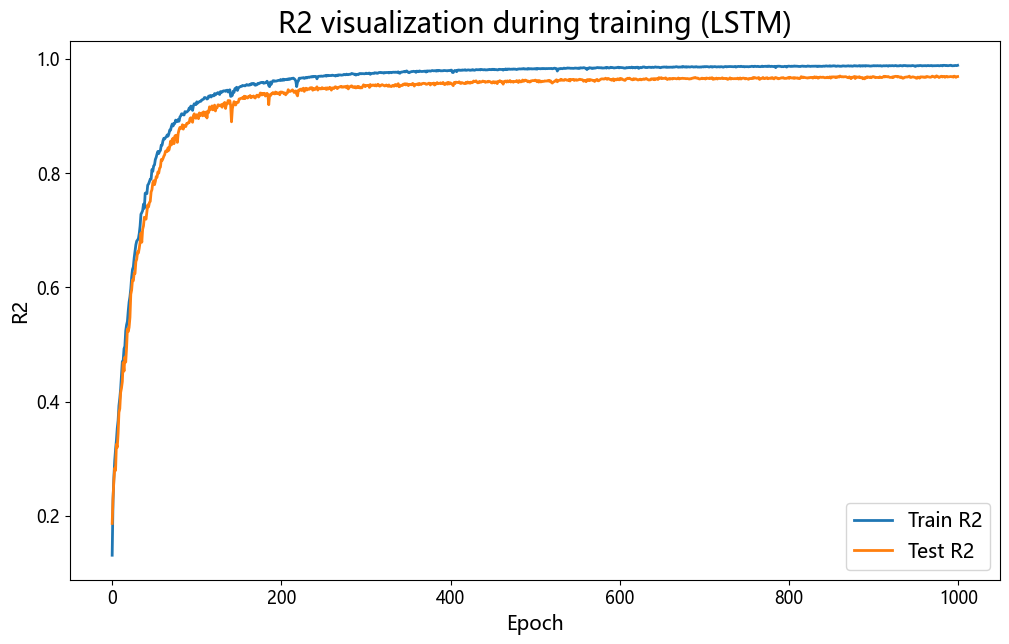

In [ ]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(12, 7), dpi=100)  # 定义画布
ax.plot(train_r2_records, marker="", linestyle="-", linewidth=2, label="Train R2")  # 画训练集R2曲线
ax.plot(test_r2_records, marker="", linestyle="-", linewidth=2, label="Test R2")  # 画测试集R2曲线
ax.set_title("R2 visualization during training (LSTM)", fontsize=20)  # 标题
ax.set_xlabel("Epoch", fontsize=14)  # x轴标签
ax.set_ylabel("R2", fontsize=14)  # y轴标签
ax.tick_params(labelsize=12)  # 设置坐标轴轴刻度大小
ax.legend(loc="best", prop={"size": 14})  # 图例
plt.show()  # 显示图像
plt.close()  # 关闭图像

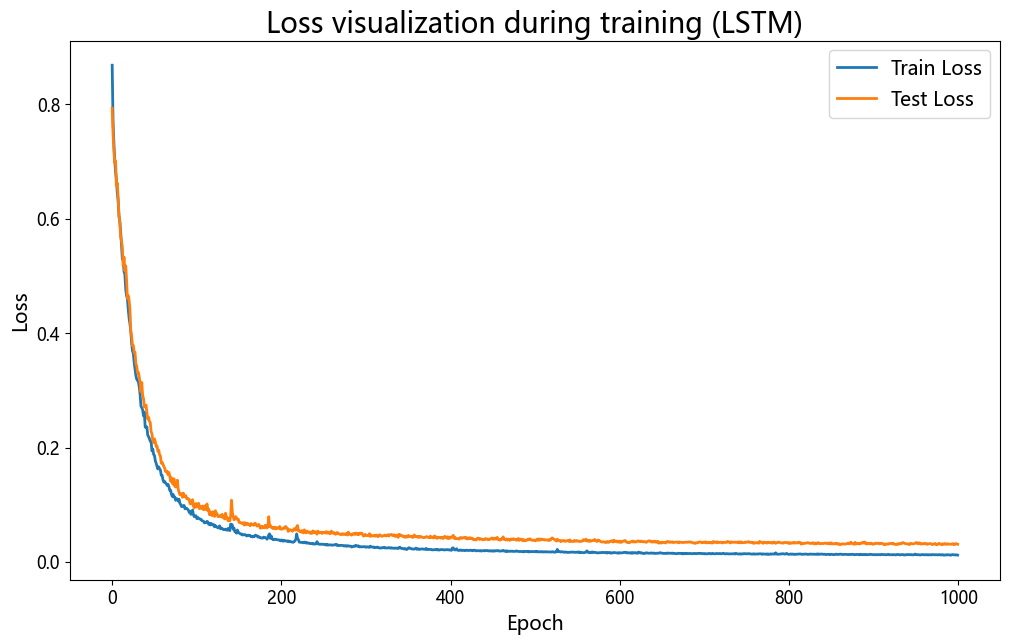

In [ ]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(12, 7), dpi=100)  # 定义画布
ax.plot(train_loss_records, marker="", linestyle="-", linewidth=2, label="Train Loss")  # 画训练集Loss曲线
ax.plot(test_loss_records, marker="", linestyle="-", linewidth=2, label="Test Loss")  # 画测试集Loss曲线
ax.set_title("Loss visualization during training (LSTM)", fontsize=20)  # 标题
ax.set_xlabel("Epoch", fontsize=14)  # x轴标签
ax.set_ylabel("Loss", fontsize=14)  # y轴标签
ax.tick_params(labelsize=12)  # 设置坐标轴轴刻度大小
ax.legend(loc="best", prop={"size": 14})  # 图例
plt.show()  # 显示图像
plt.close()  # 关闭图像

In [ ]:
lstm_model = LSTMModel(inputs_size=X_train.shape[-1], outputs_size=1).to(device)  # 定义模型
lstm_model.load_state_dict(torch.load(os.path.join(outputs_dir, "lstm_model.pt")))  # 加载模型
lstm_model.eval()  # 测试模式

# 预测训练集
y_train_pred_of_lstm = []  # 训练集预测值
for inputs, targets in tqdm(train_loader, file=sys.stdout):  # 训练集批量预测
    outputs = lstm_model(inputs.to(device))  # 前向传播
    y_train_pred_of_lstm.extend(outputs.detach().cpu().numpy().tolist())  # 记录预测值

# 反标准化
y_train_of_lstm = y_scaler.inverse_transform(y_train.reshape(-1, 1)).reshape(-1).tolist()
y_train_pred_of_lstm = y_scaler.inverse_transform(y_train_pred_of_lstm).reshape(-1).tolist()

# 计算训练集指标
print("LSTM Model - Training Set:")
print(f"MAE: {mean_absolute_error(y_train_of_lstm, y_train_pred_of_lstm)}")  # 平均绝对误差
print(f"MSE: {mean_squared_error(y_train_of_lstm, y_train_pred_of_lstm)}")  # 均方误差
print(f"RMSE: {np.sqrt(mean_squared_error(y_train_of_lstm, y_train_pred_of_lstm))}")  # 均方根误差
print(f"R2: {r2_score(y_train_of_lstm, y_train_pred_of_lstm)}")  # R²

y_test_pred_of_lstm = []  # 测试集预测值
for inputs, targets in tqdm(test_loader, file=sys.stdout):  # 循环每一个batch
    outputs = lstm_model(inputs.to(device))  # 前向传播
    y_test_pred_of_lstm.extend(outputs.detach().cpu().numpy().tolist())  # 记录预测值

y_test_of_lstm = y_scaler.inverse_transform(y_test.reshape(-1, 1)).reshape(-1).tolist()  # 反标准化
y_test_pred_of_lstm = y_scaler.inverse_transform(y_test_pred_of_lstm).reshape(-1).tolist()  # 反标准化

print("LSTM Model:")
print(f"MAE: {mean_absolute_error(y_test_of_lstm, y_test_pred_of_lstm)}")  # 平均绝对误差
print(f"MSE: {mean_squared_error(y_test_of_lstm, y_test_pred_of_lstm)}")  # 均方误差
print(f"RMSE: {np.sqrt(mean_squared_error(y_test_of_lstm, y_test_pred_of_lstm))}")  # 均方根误差
print(f"R2: {r2_score(y_test_of_lstm, y_test_pred_of_lstm)}")  # R2

100%|██████████| 91/91 [00:01<00:00, 85.61it/s]
LSTM Model - Training Set:
MAE: 0.6337324147182515
MSE: 0.7111302904750783
RMSE: 0.8432854145988049
R2: -1.0434807869928155
100%|██████████| 23/23 [00:00<00:00, 90.59it/s]
LSTM Model:
MAE: 0.06836216909780693
MSE: 0.010297863134785843
RMSE: 0.10147838752555069
R2: 0.9698488979107021


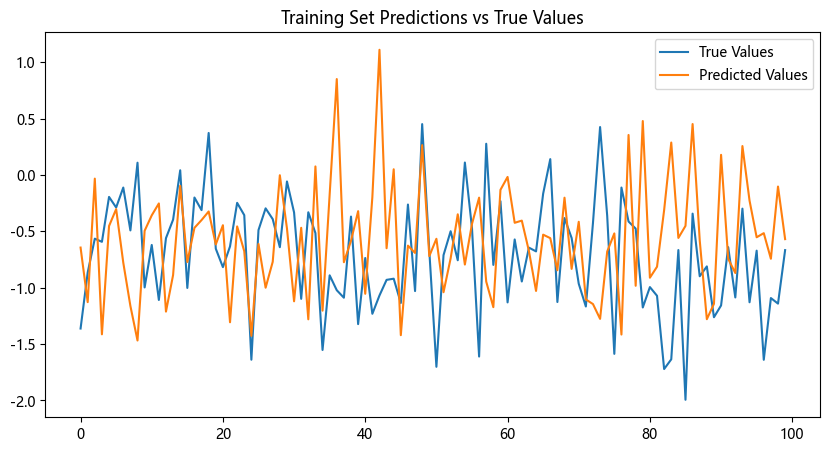

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(y_train_of_lstm[:100], label="True Values")
plt.plot(y_train_pred_of_lstm[:100], label="Predicted Values")
plt.legend()
plt.title("Training Set Predictions vs True Values")
plt.show()


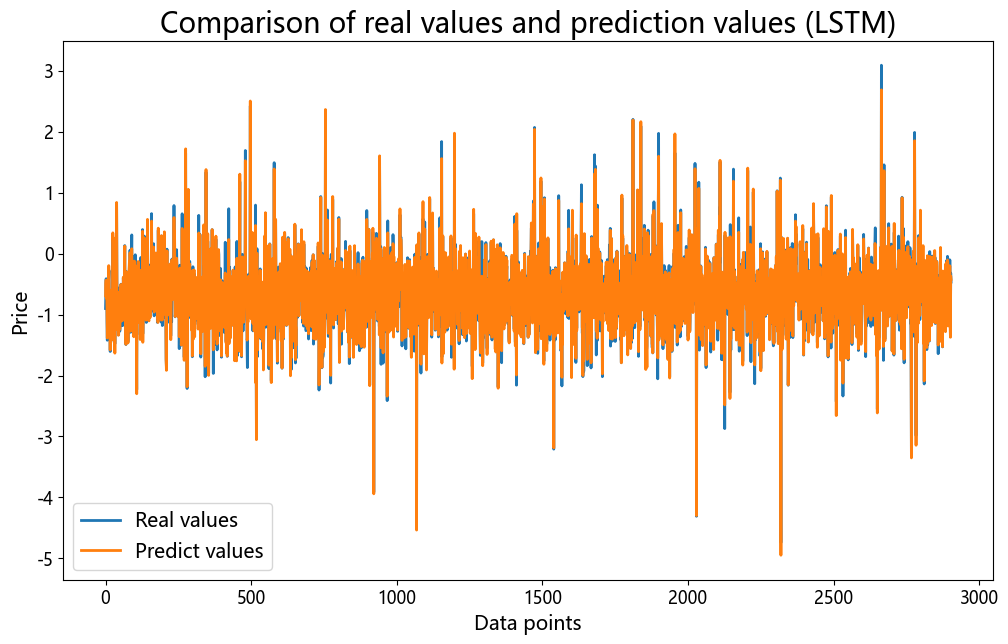

In [ ]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(12, 7), dpi=100)  # 定义画布
ax.plot(y_test_of_lstm, marker="", linestyle="-", linewidth=2, label="Real values")  # 画真实值
ax.plot(y_test_pred_of_lstm, marker="", linestyle="-", linewidth=2, label="Predict values")  # 画预测值
ax.set_title("Comparison of real values and prediction values (LSTM)", fontsize=20)  # 标题
ax.set_xlabel("Data points", fontsize=14)  # x轴标签
ax.set_ylabel("Price", fontsize=14)  # y轴标签
ax.tick_params(labelsize=12)  # 设置坐标轴轴刻度大小
ax.legend(loc="best", prop={"size": 14})  # 图例
plt.show()  # 显示图像
plt.close()  # 关闭图像

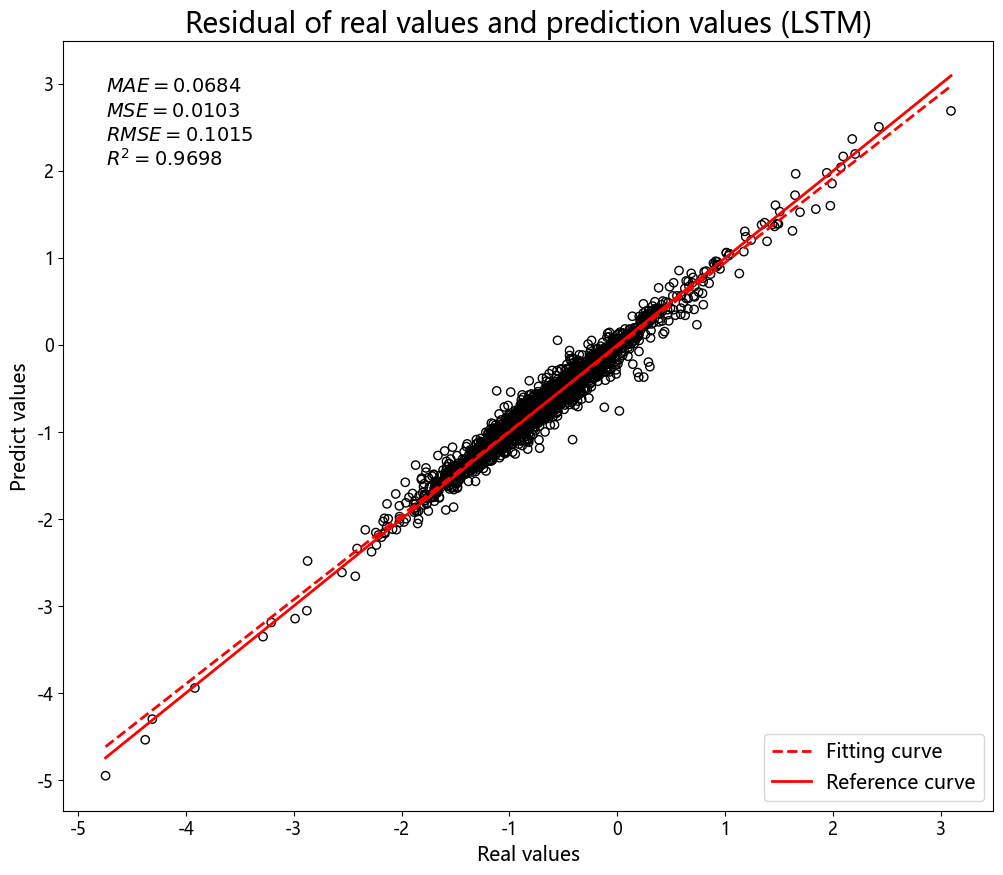

In [ ]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(12, 10), dpi=100)  # 定义画布
ax.text(
    min(y_test_of_lstm),
    max(y_test_of_lstm),
    f"$MAE={round(mean_absolute_error(y_test_of_lstm, y_test_pred_of_lstm), 4)}$"
    f"\n$MSE={round(mean_squared_error(y_test_of_lstm, y_test_pred_of_lstm), 4)}$"
    f"\n$RMSE={round(pow(mean_squared_error(y_test_of_lstm, y_test_pred_of_lstm), 0.5), 4)}$"
    f"\n$R^2={round(r2_score(y_test_of_lstm, y_test_pred_of_lstm), 4)}$",
    verticalalignment="top",
    fontdict={"size": 14, "color": "k"},
)  # 左上角显示模型性能指标
ax.scatter(y_test_of_lstm, y_test_pred_of_lstm, c="none", marker="o", edgecolors="k")  # 散点图
if True:  # 是否画拟合曲线
    from sklearn.linear_model import LinearRegression
    fitting_model = LinearRegression()
    fitting_model.fit([[item] for item in y_test_of_lstm], y_test_pred_of_lstm)
    ax.plot(
        [min(y_test_of_lstm), max(y_test_of_lstm)],
        [
            fitting_model.predict([[min(y_test_of_lstm)]]).item(),
            fitting_model.predict([[max(y_test_of_lstm)]]).item(),
        ],
        linewidth=2,
        linestyle="--",
        color="r",
        label="Fitting curve",
    )  # 拟合曲线
ax.plot(
    [min(y_test_of_lstm), max(y_test_of_lstm)],
    [min(y_test_of_lstm), max(y_test_of_lstm)],
    linewidth=2,
    linestyle="-",
    color="r",
    label="Reference curve",
)  # 参考曲线
ax.set_title("Residual of real values and prediction values (LSTM)", fontsize=20)  # 标题
ax.set_xlabel("Real values", fontsize=14)  # x轴标签
ax.set_ylabel("Predict values", fontsize=14)  # y轴标签
ax.tick_params(labelsize=12)  # 设置坐标轴轴刻度大小
ax.legend(loc="lower right", prop={"size": 14})  # 图例
plt.show()  # 显示图像
plt.close()  # 关闭图像

### 模型对比

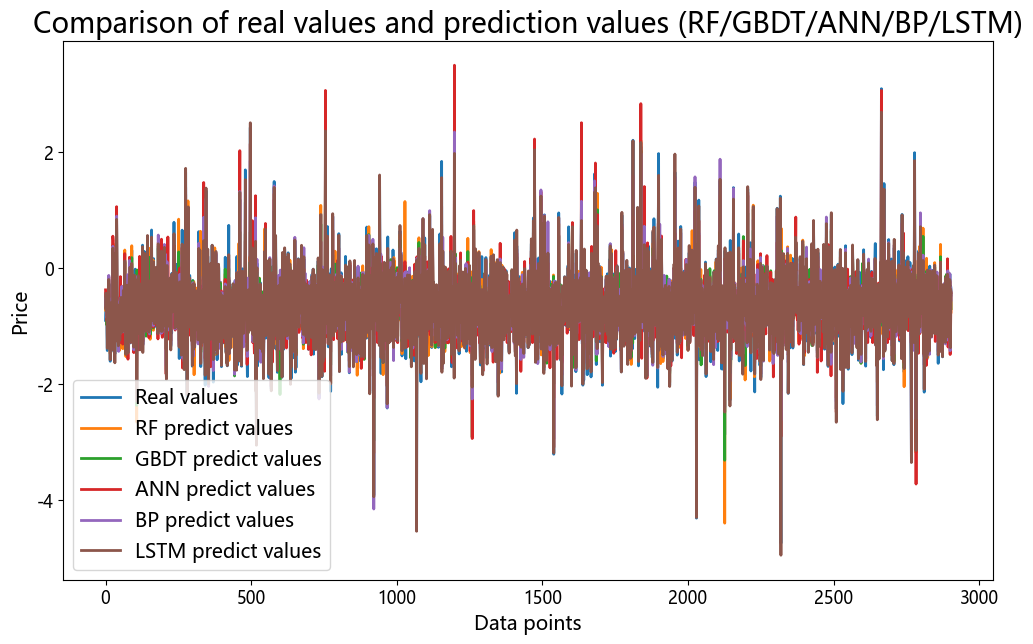

In [ ]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(12, 7), dpi=100)  # 定义画布
ax.plot(y_test_of_lstm, marker="", linestyle="-", linewidth=2, label="Real values")  # 画真实值
ax.plot(y_test_pred_of_rf, marker="", linestyle="-", linewidth=2, label="RF predict values")  # 画预测值
ax.plot(y_test_pred_of_gbdt, marker="", linestyle="-", linewidth=2, label="GBDT predict values")  # 画预测值
ax.plot(y_test_pred_of_ann, marker="", linestyle="-", linewidth=2, label="ANN predict values")  # 画预测值
ax.plot(y_test_pred_of_bp, marker="", linestyle="-", linewidth=2, label="BP predict values")  # 画预测值
ax.plot(y_test_pred_of_lstm, marker="", linestyle="-", linewidth=2, label="LSTM predict values")  # 画预测值
ax.set_title("Comparison of real values and prediction values (RF/GBDT/ANN/BP/LSTM)", fontsize=20)  # 标题
ax.set_xlabel("Data points", fontsize=14)  # x轴标签
ax.set_ylabel("Price", fontsize=14)  # y轴标签
ax.tick_params(labelsize=12)  # 设置坐标轴轴刻度大小
ax.legend(loc="best", prop={"size": 14})  # 图例
plt.show()  # 显示图像
plt.close()  # 关闭图像

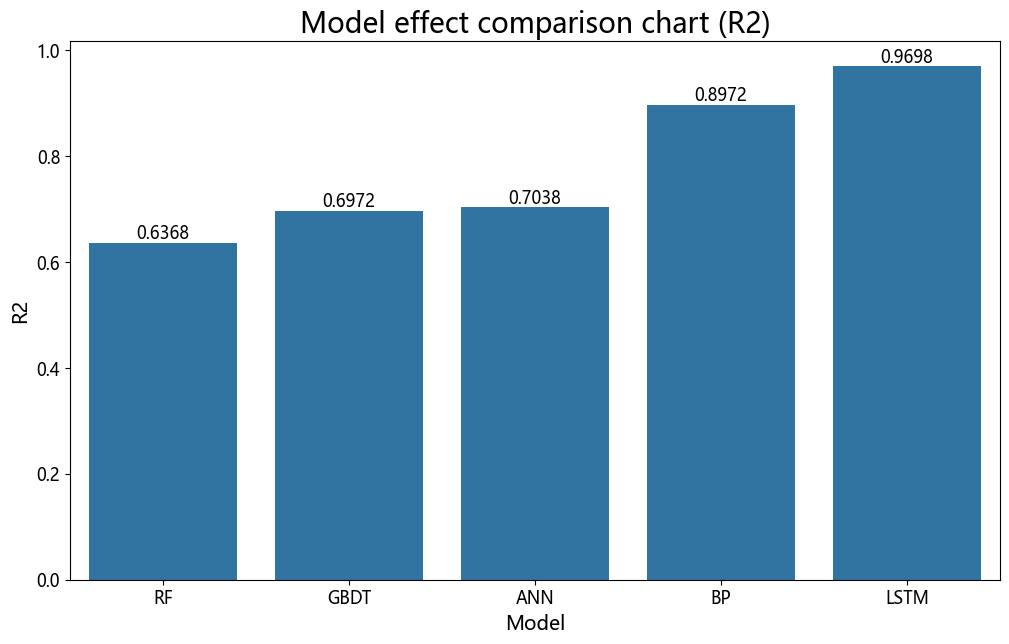

In [ ]:
models = ["RF", "GBDT", "ANN", "BP", "LSTM"]  # 模型名称
r2s = [
    r2_score(y_test_of_rf, y_test_pred_of_rf),
    r2_score(y_test_of_gbdt, y_test_pred_of_gbdt),
    r2_score(y_test_of_ann, y_test_pred_of_ann),
    r2_score(y_test_of_bp, y_test_pred_of_bp),
    r2_score(y_test_of_lstm, y_test_pred_of_lstm),
]  # 准确率

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(12, 7), dpi=100)  # 定义画布
sns.barplot(x=models, y=r2s, ax=ax)  # 画条形图
for x, y in zip(range(len(models)), [round(item, 4) for item in r2s]):  # 遍历所有特征
    ax.text(x=x, y=y, s=round(y, 4), ha="center", va="bottom", fontdict={"size": 12})  # 在条形图上显示数字
ax.set_title("Model effect comparison chart (R2)", fontsize=20)  # 标题
ax.set_xlabel("Model", fontsize=14)  # x轴标签
ax.set_ylabel("R2", fontsize=14)  # y轴标签
ax.tick_params(labelsize=12)  # 设置坐标轴轴刻度大小
plt.show()  # 显示图像
plt.close()  # 关闭图像

In [ ]:
# 保存r2数据画图
# Combine the data (you could save each model's data separately, but here we save them together)
plt_data = {
    'y_test_rf': y_test_of_rf,
    'y_pred_rf': y_test_pred_of_rf,
    'y_test_gbdt': y_test_of_gbdt,
    'y_pred_gbdt': y_test_pred_of_gbdt,
    'y_test_ann': y_test_of_ann,
    'y_pred_ann': y_test_pred_of_ann,
    'y_test_lstm': y_test_of_lstm,
    'y_pred_lstm': y_test_pred_of_lstm
}

# Save the data to a .npz file
np.savez('model_result1.npz', **plt_data)

In [ ]:
# X_full = np.vstack((X_train, X_test))
# y_full = np.hstack((y_train, y_test))
# # 重新标准化
# X_scaler = StandardScaler()
# X_full = X_scaler.fit_transform(X_full)
# save_pkl(os.path.join(outputs_dir, "X_scaler.pkl"), X_scaler)  # 保存 X_scaler
# y_scaler = StandardScaler()
# y_full = y_scaler.fit_transform(y_full.reshape(-1, 1)).reshape(-1)
# save_pkl(os.path.join(outputs_dir, "y_scaler.pkl"), y_scaler)  # 保存 y_scaler

# rf_model.fit(X_full, y_full)  # 训练模型
# gbdt_model.fit(X_full, y_full)
# ann_model.fit(X_full, y_full)
# lstm_model.fit(X_full, y_full)

# # 保存最终的 RF 模型
# save_pkl(os.path.join(outputs_dir, "rf_model.pkl"), rf_model)
# save_pkl(os.path.join(outputs_dir, "gbdt_model.pkl"), gbdt_model)
# save_pkl(os.path.join(outputs_dir, "ann_model.pkl"), ann_model)
# save_pkl(os.path.join(outputs_dir, "lstm_model.pkl"), lstm_model)